In [2]:
import numpy as np
import pandas as pd

# rdkit functions
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors

In [3]:
# load data
df = pd.read_csv('./gslf_and_human_data.csv')
smiles_list = list(df['smiles'])
label = list(df['label'])

# embed odors into rdkit descriptor vectors
data_matrix = []
functional_groups = []
for smi in smiles_list:
    mol = Chem.MolFromSmiles(smi)
    descriptor_dict = Descriptors.CalcMolDescriptors(mol)
    desc_vector = list(descriptor_dict.values())
    data_matrix.append(desc_vector)

data_matrix = np.array(data_matrix)

# remove nans
nan_cols = np.unique(np.where(np.isnan(data_matrix))[1])
data_matrix = np.delete(data_matrix, nan_cols, axis=1)

In [4]:
data_matrix

array([[ 4.24203704,  4.24203704,  1.07638889, ...,  0.        ,
         0.        ,  0.        ],
       [ 4.32425926,  4.32425926,  0.56287037, ...,  0.        ,
         0.        ,  0.        ],
       [ 4.31314815,  4.31314815,  0.95657407, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [12.3299194 , 12.3299194 ,  0.58849271, ...,  0.        ,
         0.        ,  0.        ],
       [14.83846027, 14.83846027,  0.02170942, ...,  0.        ,
         0.        ,  0.        ],
       [14.35132867, 14.35132867,  0.        , ...,  0.        ,
         0.        ,  0.        ]], shape=(5841, 205))

In [5]:
print(f'{data_matrix.shape} odorants x rd descriptors')

(5841, 205) odorants x rd descriptors


Initial shape: (5841, 205)
After removing constant features: (5841, 193)
Adaptive epsilon = 5.028


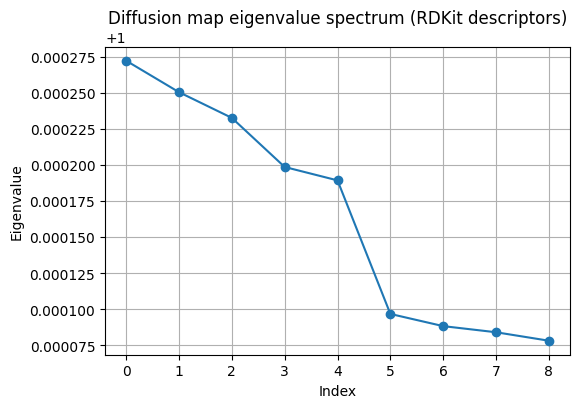

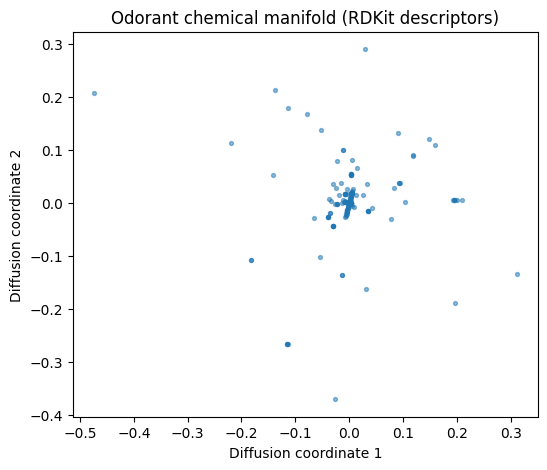

In [17]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# 1. Load your descriptor matrix
# -------------------------------------------------------------------
# If it's a NumPy array already:
X = data_matrix.copy()

print("Initial shape:", X.shape)

# -------------------------------------------------------------------
# 2. Remove zero-variance or all-zero columns
# -------------------------------------------------------------------
mask = X.std(axis=0) > 1e-6
X = X[:, mask]
print("After removing constant features:", X.shape)

# -------------------------------------------------------------------
# 3. Standardize features (zero mean, unit variance)
# -------------------------------------------------------------------
scaler = StandardScaler()
X = scaler.fit_transform(X)

# -------------------------------------------------------------------
# 4. Compute pairwise Euclidean distances
# -------------------------------------------------------------------
D = pairwise_distances(X, metric='euclidean')

# -------------------------------------------------------------------
# 5. Choose adaptive epsilon (local scale)
# -------------------------------------------------------------------
k = 10
eps = np.median(np.sort(D, axis=1)[:, k])
print(f"Adaptive epsilon = {eps:.3f}")

# -------------------------------------------------------------------
# 6. Build Gaussian kernel with α-normalization
# -------------------------------------------------------------------
K = np.exp(-D**2 / (2 * eps**2))
alpha = 0.5
q = K.sum(axis=1)
K = K / np.outer(q**alpha, q**alpha)
P = K / K.sum(axis=1, keepdims=True)

# -------------------------------------------------------------------
# 7. Compute eigen-decomposition (diffusion coordinates)
# -------------------------------------------------------------------
vals, vecs = eigsh(P, k=10)
idx = np.argsort(-vals)
vals, vecs = vals[idx], vecs[:, idx]

eigvals = vals[1:]
coords = vecs[:, 1:4] * vals[1:4]

# -------------------------------------------------------------------
# 8. Plot eigenvalue spectrum
# -------------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(eigvals, 'o-')
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.title("Diffusion map eigenvalue spectrum (RDKit descriptors)")
plt.grid(True)
plt.show()

# -------------------------------------------------------------------
# 9. Plot first two diffusion coordinates
# -------------------------------------------------------------------
plt.figure(figsize=(6,5))
plt.scatter(coords[:,0], coords[:,1], s=8, alpha=0.5)
plt.xlabel("Diffusion coordinate 1")
plt.ylabel("Diffusion coordinate 2")
plt.title("Odorant chemical manifold (RDKit descriptors)")
plt.show()


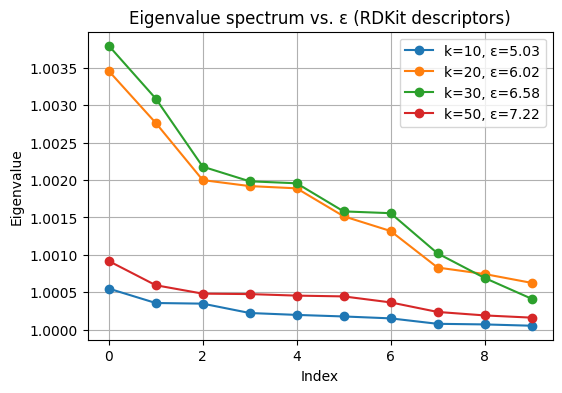

In [19]:
from sklearn.metrics import pairwise_distances
from scipy.sparse.linalg import eigsh
import numpy as np, matplotlib.pyplot as plt

# recompute pairwise distances
D = pairwise_distances(X, metric='euclidean')

plt.figure(figsize=(6,4))
for k in [10, 20, 30, 50]:
    eps = np.median(np.sort(D, axis=1)[:, k])
    K = np.exp(-D**2 / (2 * eps**2))

    alpha = 0.5
    q = K.sum(axis=1)
    K = K / np.outer(q**alpha, q**alpha)
    P = K / K.sum(axis=1, keepdims=True)

    vals, _ = eigsh(P, k=10)
    vals = np.sort(vals)[::-1]
    plt.plot(vals, 'o-', label=f'k={k}, ε={eps:.2f}')

plt.legend()
plt.title("Eigenvalue spectrum vs. ε (RDKit descriptors)")
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.grid(True)
plt.show()

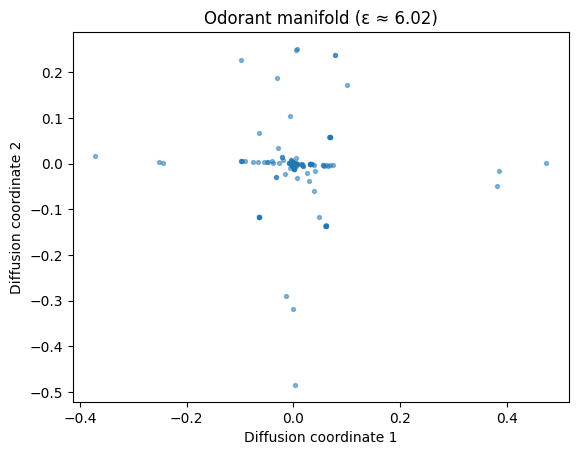

In [20]:
# pick ε from the sweet spot
k = 20
eps = np.median(np.sort(D, axis=1)[:, k])
K = np.exp(-D**2 / (2 * eps**2))
alpha = 0.5
q = K.sum(axis=1)
K = K / np.outer(q**alpha, q**alpha)
P = K / K.sum(axis=1, keepdims=True)

vals, vecs = eigsh(P, k=6)
idx = np.argsort(-vals)
vals, vecs = vals[idx], vecs[:, idx]

coords = vecs[:, 1:3] * vals[1:3]

plt.scatter(coords[:,0], coords[:,1], s=8, alpha=0.5)
plt.xlabel("Diffusion coordinate 1")
plt.ylabel("Diffusion coordinate 2")
plt.title(f"Odorant manifold (ε ≈ {eps:.2f})")
plt.show()


In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50, random_state=0)
X_pca = pca.fit_transform(X)
print(f"Explained variance (first 50 PCs): {pca.explained_variance_ratio_.sum():.2f}")

Explained variance (first 50 PCs): 0.84


Adaptive epsilon = 0.127


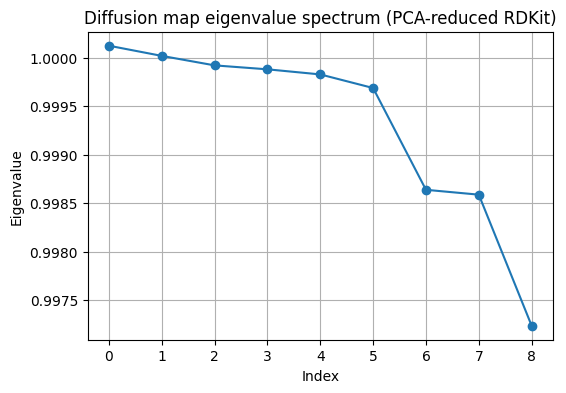

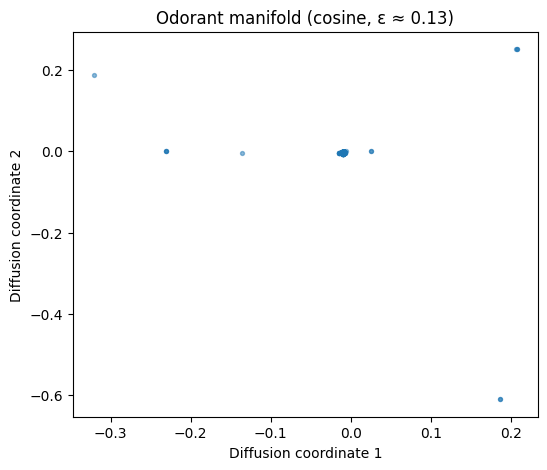

In [22]:
# --------------------------------------------
# Diffusion map on PCA-reduced RDKit features
# --------------------------------------------
from sklearn.metrics import pairwise_distances
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
import numpy as np

# 1. Pairwise distances (cosine works better for chem descriptors)
D = pairwise_distances(X_pca, metric='cosine')

# 2. Adaptive epsilon
k = 20
eps = np.median(np.sort(D, axis=1)[:, k])
print(f"Adaptive epsilon = {eps:.3f}")

# 3. Gaussian kernel with α-normalization
K = np.exp(-D**2 / (2 * eps**2))
alpha = 0.5
q = K.sum(axis=1)
K = K / np.outer(q**alpha, q**alpha)
P = K / K.sum(axis=1, keepdims=True)

# 4. Eigen-decomposition
vals, vecs = eigsh(P, k=10)
idx = np.argsort(-vals)
vals, vecs = vals[idx], vecs[:, idx]

eigvals = vals[1:]
coords = vecs[:, 1:4] * vals[1:4]

# 5. Spectrum
plt.figure(figsize=(6,4))
plt.plot(eigvals, 'o-')
plt.title("Diffusion map eigenvalue spectrum (PCA-reduced RDKit)")
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.grid(True)
plt.show()

# 6. Embedding
plt.figure(figsize=(6,5))
plt.scatter(coords[:,0], coords[:,1], s=8, alpha=0.5)
plt.xlabel("Diffusion coordinate 1")
plt.ylabel("Diffusion coordinate 2")
plt.title(f"Odorant manifold (cosine, ε ≈ {eps:.2f})")
plt.show()


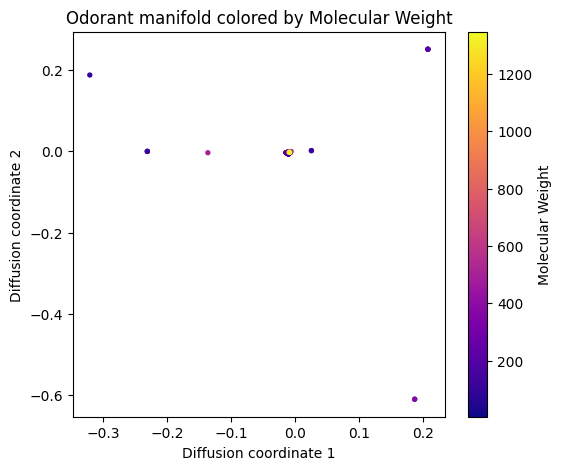

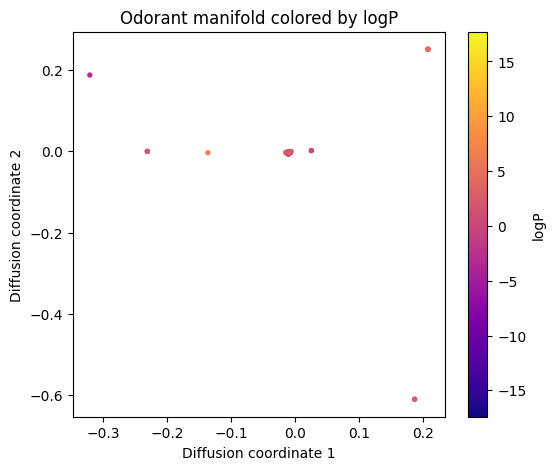

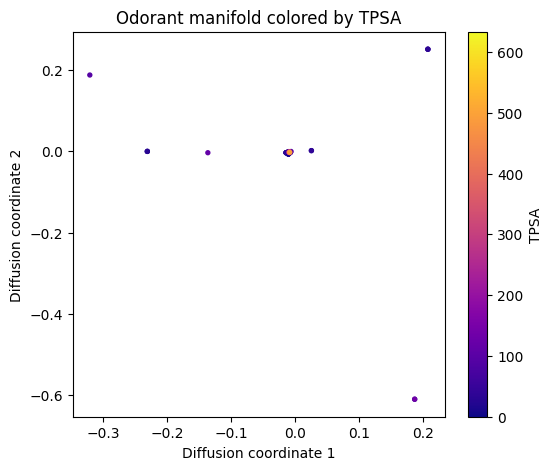

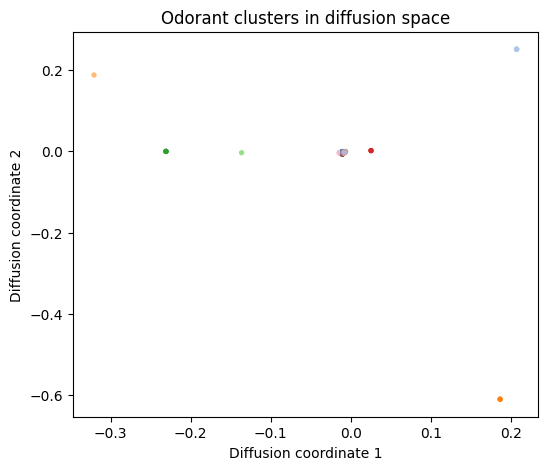

✅ Saved cluster table: odorant_diffusionmap_clusters.csv


In [26]:
# ============================================================
# Compute chemical properties and visualize diffusion manifold
# ============================================================

from rdkit import Chem
from rdkit.Chem import Descriptors
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# 1. Create RDKit molecule objects
# ------------------------------------------------------------
# Replace this with your actual list or DataFrame column of SMILES:
# Example: df['smiles'] if you loaded odorants from a CSV
smiles_list = df["smiles"].tolist()
mols = [Chem.MolFromSmiles(s) for s in smiles_list]

# ------------------------------------------------------------
# 2. Compute basic chemical properties for visualization
# ------------------------------------------------------------
MolWt = np.array([Descriptors.MolWt(m) for m in mols])
logP  = np.array([Descriptors.MolLogP(m) for m in mols])
TPSA  = np.array([Descriptors.TPSA(m) for m in mols])

props = {"Molecular Weight": MolWt, "logP": logP, "TPSA": TPSA}

# ------------------------------------------------------------
# 3. Plot diffusion map embeddings colored by each property
# ------------------------------------------------------------
for name, prop in props.items():
    plt.figure(figsize=(6,5))
    plt.scatter(coords[:,0], coords[:,1], c=prop, cmap="plasma", s=8)
    plt.colorbar(label=name)
    plt.xlabel("Diffusion coordinate 1")
    plt.ylabel("Diffusion coordinate 2")
    plt.title(f"Odorant manifold colored by {name}")
    plt.show()

# ------------------------------------------------------------
# 4. Cluster odorants in diffusion space
# ------------------------------------------------------------
kmeans = KMeans(n_clusters=20, random_state=0)
labels = kmeans.fit_predict(coords[:, :5])

plt.figure(figsize=(6,5))
plt.scatter(coords[:,0], coords[:,1], c=labels, cmap="tab20", s=8)
plt.xlabel("Diffusion coordinate 1")
plt.ylabel("Diffusion coordinate 2")
plt.title("Odorant clusters in diffusion space")
plt.show()

# ------------------------------------------------------------
# 5. Optional: save clusters or combined table
# ------------------------------------------------------------
df_out = pd.DataFrame({
    "smiles": smiles_list,
    "MolWt": MolWt,
    "logP": logP,
    "TPSA": TPSA,
    "cluster": labels
})
df_out.to_csv("odorant_diffusionmap_clusters.csv", index=False)
print("✅ Saved cluster table: odorant_diffusionmap_clusters.csv")

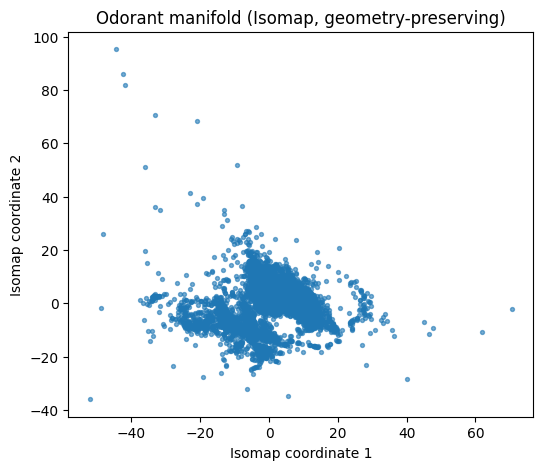

Selected 200 representative molecules.


In [27]:
# ============================================================
# Geometry-preserving manifold (Isomap) for sampling
# ============================================================
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
from sklearn.metrics import pairwise_distances
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# 1. PCA to denoise
pca = PCA(n_components=50, random_state=0)
X_pca = pca.fit_transform(X)

# 2. Isomap embedding (preserves geodesic distances)
iso = Isomap(n_neighbors=30, n_components=3)
iso_coords = iso.fit_transform(X_pca)

# 3. Visualize
plt.figure(figsize=(6,5))
plt.scatter(iso_coords[:,0], iso_coords[:,1], s=8, alpha=0.6)
plt.xlabel("Isomap coordinate 1")
plt.ylabel("Isomap coordinate 2")
plt.title("Odorant manifold (Isomap, geometry-preserving)")
plt.show()

# 4. Sample uniformly across manifold using K-means
n_samples = 200  # number of representative odorants to pick
km = KMeans(n_clusters=n_samples, random_state=0)
labels = km.fit_predict(iso_coords)
sample_indices = np.argmin(pairwise_distances(iso_coords, km.cluster_centers_), axis=0)

print(f"Selected {len(sample_indices)} representative molecules.")


Explained variance (first 50 PCs): 0.84


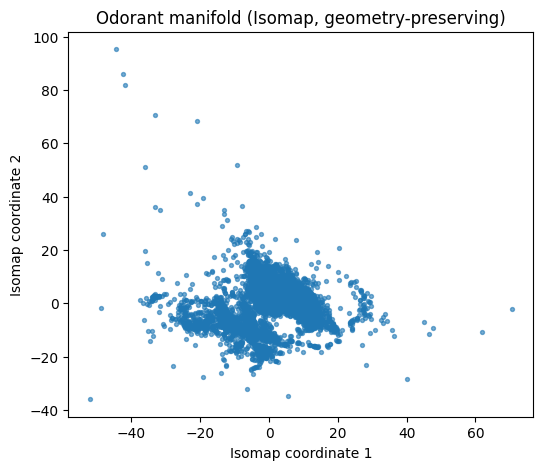

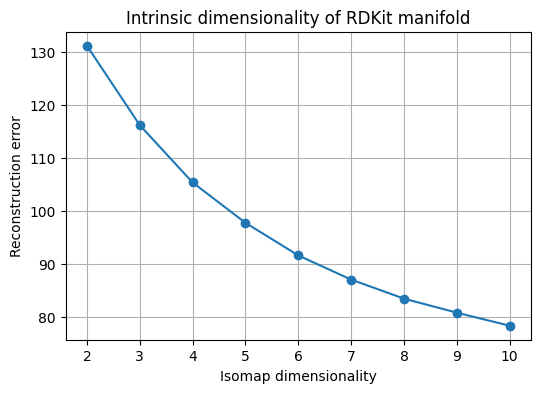

Selected 200 representative odorants.


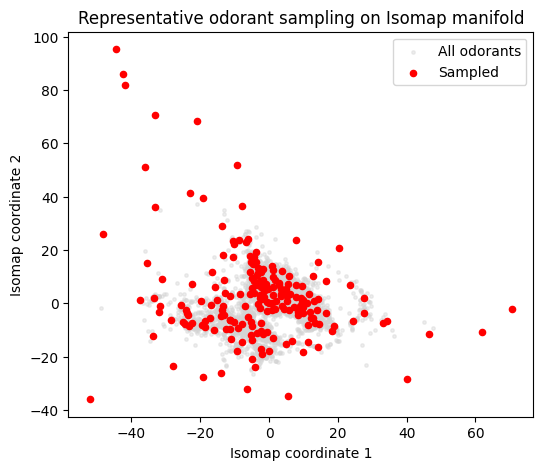

✅ Saved representative odorant set to 'representative_odorants_isomap.csv'


,smiles,label
3367,CCCCCCC(C)C,['human']
2428,CC=CC(=O)OCCC(C)C,['gslf']
855,CCCCCCOC(=O)c1ccccc1,['gslf']
5300,CCCCCC(C)CCCCCCCC(=O)OC,['human']
850,CCCCCCc1ccccc1,['human']


In [29]:
# ============================================================
# Geometry-preserving sampling of odorant space using Isomap
# ============================================================

from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# 1. PCA reduction (to denoise and remove collinearity)
# ------------------------------------------------------------
pca = PCA(n_components=50, random_state=0)
X_pca = pca.fit_transform(X)
print(f"Explained variance (first 50 PCs): {pca.explained_variance_ratio_.sum():.2f}")

# ------------------------------------------------------------
# 2. Isomap embedding (preserves geodesic geometry)
# ------------------------------------------------------------
iso = Isomap(n_neighbors=30, n_components=3)
iso_coords = iso.fit_transform(X_pca)

plt.figure(figsize=(6,5))
plt.scatter(iso_coords[:,0], iso_coords[:,1], s=8, alpha=0.6)
plt.xlabel("Isomap coordinate 1")
plt.ylabel("Isomap coordinate 2")
plt.title("Odorant manifold (Isomap, geometry-preserving)")
plt.show()

# ------------------------------------------------------------
# 3. Estimate intrinsic dimensionality (reconstruction error curve)
# ------------------------------------------------------------
dims = range(2, 11)
residuals = []
for d in dims:
    iso_d = Isomap(n_neighbors=30, n_components=d)
    iso_d.fit(X_pca)
    # Use method instead of attribute
    residuals.append(iso_d.reconstruction_error())

plt.figure(figsize=(6,4))
plt.plot(dims, residuals, 'o-')
plt.xlabel("Isomap dimensionality")
plt.ylabel("Reconstruction error")
plt.title("Intrinsic dimensionality of RDKit manifold")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 4. Select representative odorants via K-means clustering
# ------------------------------------------------------------
n_samples = 200  # number of representative odorants to choose
kmeans = KMeans(n_clusters=n_samples, random_state=0)
labels = kmeans.fit_predict(iso_coords)

# find the closest real data point to each cluster center
sample_indices = np.argmin(
    np.linalg.norm(iso_coords[:, None, :] - kmeans.cluster_centers_[None, :, :], axis=2),
    axis=0
)

print(f"Selected {len(sample_indices)} representative odorants.")

# ------------------------------------------------------------
# 5. Visualize sampled points
# ------------------------------------------------------------
plt.figure(figsize=(6,5))
plt.scatter(iso_coords[:,0], iso_coords[:,1], c='lightgray', s=6, alpha=0.4, label='All odorants')
plt.scatter(iso_coords[sample_indices,0], iso_coords[sample_indices,1],
            c='red', s=20, label='Sampled')
plt.xlabel("Isomap coordinate 1")
plt.ylabel("Isomap coordinate 2")
plt.title("Representative odorant sampling on Isomap manifold")
plt.legend()
plt.show()

# ------------------------------------------------------------
# 6. Save table of selected odorants (with metadata if available)
# ------------------------------------------------------------
selected_df = df.iloc[sample_indices].copy()
selected_df.to_csv("representative_odorants_isomap.csv", index=False)
print("✅ Saved representative odorant set to 'representative_odorants_isomap.csv'")

# Optionally inspect top few selections
selected_df.head()


Trustworthiness:
  PCA   = 0.8390
  Isomap = 0.8730
Distance correlation (Spearman):
  PCA   = 0.7105
  Isomap = 0.7387


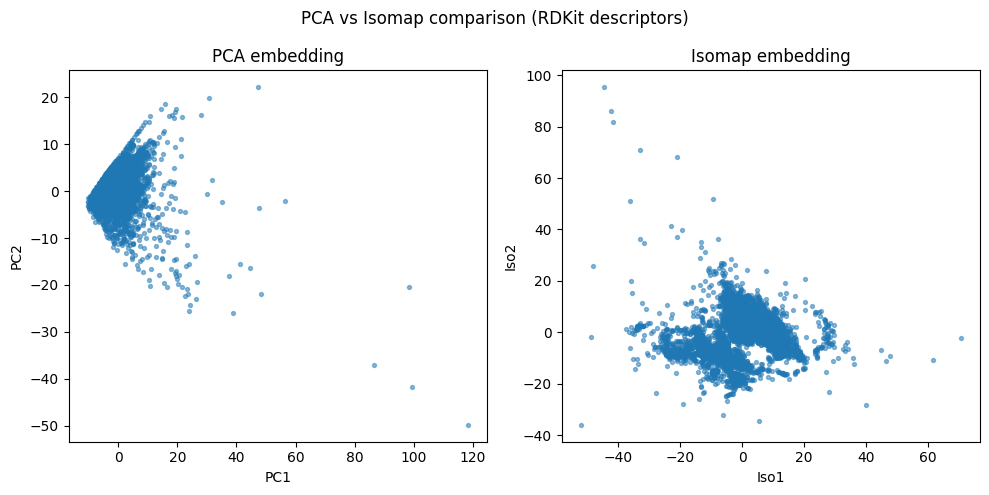

In [30]:
# ============================================================
# Compare Isomap vs PCA for RDKit descriptor geometry
# ============================================================

from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
from sklearn.metrics import pairwise_distances
from sklearn.manifold import trustworthiness
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ------------------------------------------------------------
# 1. Compute both embeddings
# ------------------------------------------------------------
pca = PCA(n_components=3, random_state=0)
pca_coords = pca.fit_transform(X)

iso = Isomap(n_neighbors=30, n_components=3)
iso_coords = iso.fit_transform(X_pca)   # use PCA-reduced X if you did that step

# ------------------------------------------------------------
# 2. Compute trustworthiness (higher is better)
# ------------------------------------------------------------
trust_pca = trustworthiness(X, pca_coords, n_neighbors=30)
trust_iso = trustworthiness(X, iso_coords, n_neighbors=30)

print(f"Trustworthiness:\n  PCA   = {trust_pca:.4f}\n  Isomap = {trust_iso:.4f}")

# ------------------------------------------------------------
# 3. Compute stress (distance correlation between embeddings)
# ------------------------------------------------------------
# use a small random subset to make pairwise distance computation manageable
subset = np.random.choice(X.shape[0], size=1000, replace=False)
D_orig = pairwise_distances(X_pca[subset], metric="euclidean")
D_pca  = pairwise_distances(pca_coords[subset], metric="euclidean")
D_iso  = pairwise_distances(iso_coords[subset], metric="euclidean")

stress_pca = spearmanr(D_orig.ravel(), D_pca.ravel()).correlation
stress_iso = spearmanr(D_orig.ravel(), D_iso.ravel()).correlation

print(f"Distance correlation (Spearman):\n  PCA   = {stress_pca:.4f}\n  Isomap = {stress_iso:.4f}")

# ------------------------------------------------------------
# 4. Visual side-by-side
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].scatter(pca_coords[:,0], pca_coords[:,1], s=8, alpha=0.5)
ax[0].set_title("PCA embedding")
ax[0].set_xlabel("PC1"); ax[0].set_ylabel("PC2")

ax[1].scatter(iso_coords[:,0], iso_coords[:,1], s=8, alpha=0.5)
ax[1].set_title("Isomap embedding")
ax[1].set_xlabel("Iso1"); ax[1].set_ylabel("Iso2")

plt.suptitle("PCA vs Isomap comparison (RDKit descriptors)")
plt.tight_layout()
plt.show()


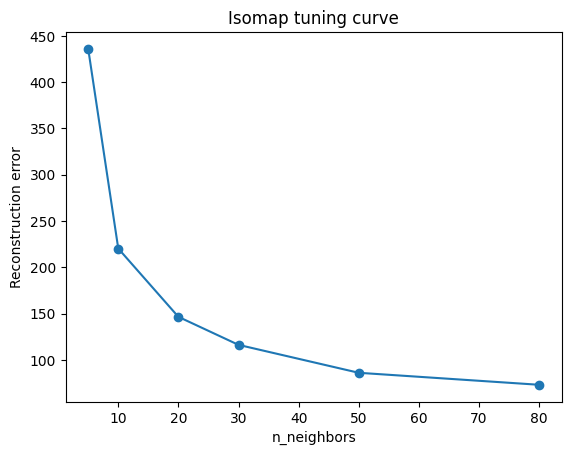

In [31]:
neighbors = [5, 10, 20, 30, 50, 80]
errors = []
for k in neighbors:
    iso = Isomap(n_neighbors=k, n_components=3)
    iso.fit(X_pca)
    errors.append(iso.reconstruction_error())
plt.plot(neighbors, errors, 'o-')
plt.xlabel("n_neighbors"); plt.ylabel("Reconstruction error")
plt.title("Isomap tuning curve")
plt.show()


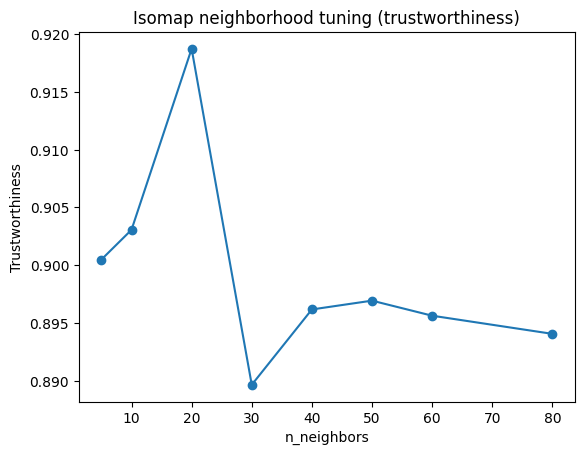

In [32]:
from sklearn.manifold import trustworthiness

neighbors = [5, 10, 20, 30, 40, 50, 60, 80]
trust = []

for k in neighbors:
    iso = Isomap(n_neighbors=k, n_components=3)
    coords = iso.fit_transform(X_pca)
    trust.append(trustworthiness(X_pca, coords, n_neighbors=30))

plt.plot(neighbors, trust, 'o-')
plt.xlabel("n_neighbors")
plt.ylabel("Trustworthiness")
plt.title("Isomap neighborhood tuning (trustworthiness)")
plt.show()


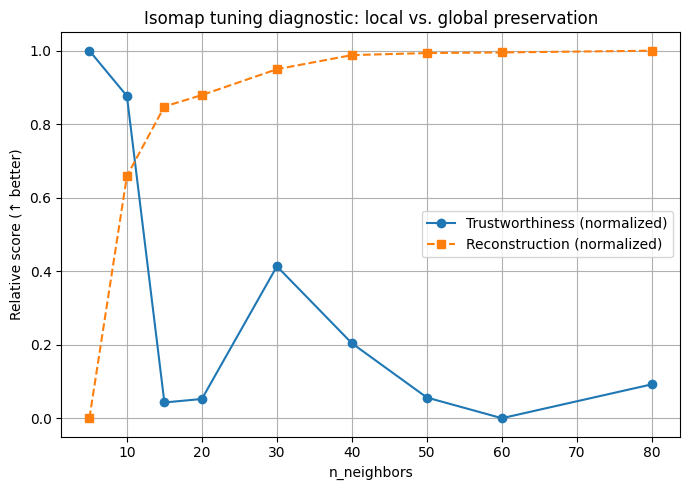

k=  5: trust=0.9147, recon=0.18
k= 10: trust=0.9108, recon=0.09
k= 15: trust=0.8849, recon=0.07
k= 20: trust=0.8852, recon=0.06
k= 30: trust=0.8964, recon=0.06
k= 40: trust=0.8899, recon=0.05
k= 50: trust=0.8853, recon=0.05
k= 60: trust=0.8835, recon=0.05
k= 80: trust=0.8864, recon=0.05


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import Isomap, trustworthiness
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ---------------------------------------------------------------------
# Assuming you already have RDKit descriptor matrix X_rd (N x D)
# ---------------------------------------------------------------------

# 1️⃣ Preprocess
X = StandardScaler().fit_transform(X)

# Optional: PCA to denoise / speed up
pca = PCA(n_components=50, random_state=0)
X_pca = pca.fit_transform(X)

# 2️⃣ Define neighborhood range
neighbors = [5, 10, 15, 20, 30, 40, 50, 60, 80]
trust, recon = [], []

# 3️⃣ Loop over neighborhood sizes
for k in neighbors:
    iso = Isomap(n_neighbors=k, n_components=3, metric='cosine')
    coords = iso.fit_transform(X_pca)

    # trustworthiness: how well local structure is preserved
    t = trustworthiness(X_pca, coords, n_neighbors=30)
    trust.append(t)

    # reconstruction error: how well global distances are preserved
    try:
        r = iso.reconstruction_error()
    except Exception:
        r = np.nan
    recon.append(r)

# 4️⃣ Normalize both metrics for comparison
trust_norm = (np.array(trust) - np.min(trust)) / (np.max(trust) - np.min(trust))
recon_norm = 1 - (np.array(recon) - np.min(recon)) / (np.max(recon) - np.min(recon))  # flip so higher=better

# 5️⃣ Plot side-by-side on same axes
plt.figure(figsize=(7,5))
plt.plot(neighbors, trust_norm, 'o-', label='Trustworthiness (normalized)')
plt.plot(neighbors, recon_norm, 's--', label='Reconstruction (normalized)')
plt.xlabel("n_neighbors")
plt.ylabel("Relative score (↑ better)")
plt.title("Isomap tuning diagnostic: local vs. global preservation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 6️⃣ Print actual metrics for reference
for k, t, r in zip(neighbors, trust, recon):
    print(f"k={k:>3d}: trust={t:.4f}, recon={r:.2f}")


Mean local distance ratio (Isomap / Raw): 0.023
Std of ratio: 0.017
Nonlinearity index (log-variance): 0.819


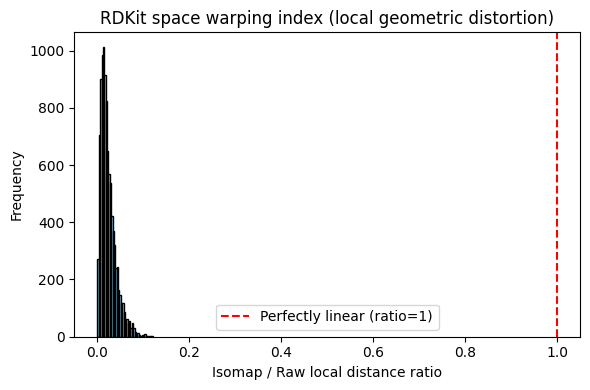

In [37]:
# =============================================================
# Quantify how warped RDKit descriptor space is
# =============================================================
import numpy as np
from sklearn.manifold import Isomap
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X = data_matrix.copy()
# 1️⃣ Standardize descriptors
X = StandardScaler().fit_transform(X)

# 2️⃣ Compute Isomap embedding (same params you’ve been using)
iso = Isomap(n_neighbors=40, n_components=3, metric='cosine')
X_iso = iso.fit_transform(X)

# 3️⃣ Pick random subset to avoid N^2 scaling
subset = np.random.choice(X.shape[0], size=1000, replace=False)
X_sub = X[subset]
X_iso_sub = X_iso[subset]

# 4️⃣ Compute local distances in each space
k = 10  # number of local neighbors
D_orig = pairwise_distances(X_sub)
D_iso = pairwise_distances(X_iso_sub)

# For each point, compare mean distance to its k nearest neighbors
def local_warp_index(D1, D2, k):
    idx = np.argsort(D1, axis=1)[:, 1:k+1]
    ratios = []
    for i in range(D1.shape[0]):
        orig_d = D1[i, idx[i]]
        iso_d = D2[i, idx[i]]
        ratios.extend(iso_d / (orig_d + 1e-9))
    return np.array(ratios)

ratios = local_warp_index(D_orig, D_iso, k)

# 5️⃣ Compute warping statistics
mean_ratio = np.mean(ratios)
std_ratio = np.std(ratios)
nonlinear_score = np.std(np.log(ratios))  # dispersion on log-scale

print(f"Mean local distance ratio (Isomap / Raw): {mean_ratio:.3f}")
print(f"Std of ratio: {std_ratio:.3f}")
print(f'Nonlinearity index (log-variance): {nonlinear_score:.3f}')

# 6️⃣ Plot histogram of local distance ratios
plt.figure(figsize=(6,4))
plt.hist(ratios, bins=40, color='skyblue', edgecolor='k')
plt.axvline(1.0, color='red', linestyle='--', label='Perfectly linear (ratio=1)')
plt.xlabel("Isomap / Raw local distance ratio")
plt.ylabel("Frequency")
plt.title("RDKit space warping index (local geometric distortion)")
plt.legend()
plt.tight_layout()
plt.show()


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.



=== Quantitative Comparison: PCA vs Isomap vs UMAP ===


,Method,Trustworthiness,DistanceCorr,CoverageMean,CoverageSD,KS_MW,KS_logP,KS_TPSA
0,PCA,0.839,0.678,9.195,6.565,0.331,0.178,0.326
1,Isomap,0.866,0.439,8.960,7.832,0.130,0.155,0.060
2,UMAP,0.954,0.238,8.780,7.514,0.105,0.140,0.088


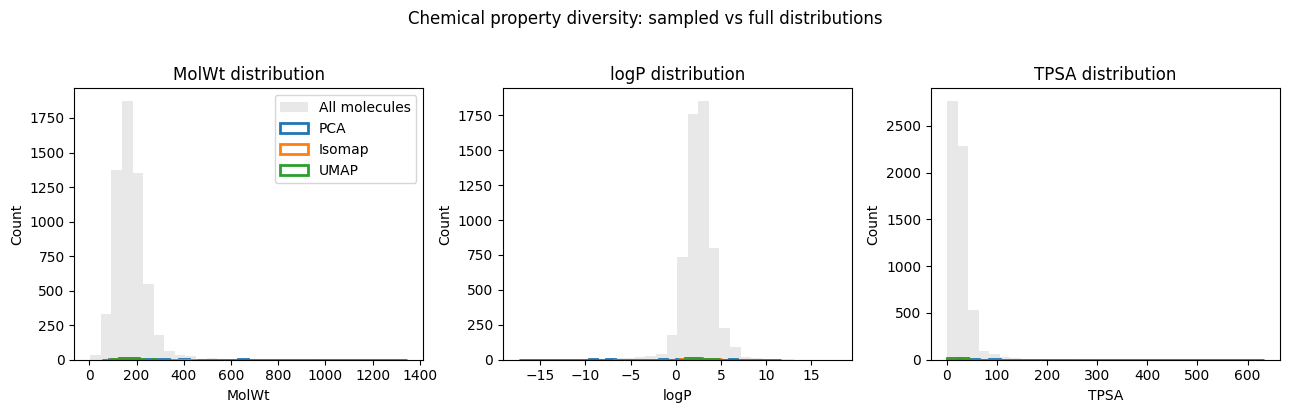

In [39]:
# =============================================================
# RDKit descriptor manifold comparison suite
# =============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, trustworthiness
import umap
from sklearn.metrics import pairwise_distances
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr, ks_2samp
from rdkit.Chem import Descriptors
import pandas as pd

# -------------------------------------------------------------
# 1️⃣  Preprocess descriptor matrix
# -------------------------------------------------------------
X = StandardScaler().fit_transform(X)

# Define embeddings
pca = PCA(n_components=3, random_state=0).fit_transform(X)
iso = Isomap(n_neighbors=40, n_components=3, metric="cosine").fit_transform(X)
uma = umap.UMAP(
    n_neighbors=40, n_components=3, min_dist=0.1,
    metric="cosine", random_state=0
).fit_transform(X)

embeddings = {"PCA": pca, "Isomap": iso, "UMAP": uma}

# -------------------------------------------------------------
# 2️⃣  Compute local/global geometry metrics
# -------------------------------------------------------------
subset = np.random.choice(X.shape[0], 1000, replace=False)
D_orig = pairwise_distances(X[subset])

trust_scores = {}
corr_scores = {}

for name, emb in embeddings.items():
    trust_scores[name] = trustworthiness(X, emb, n_neighbors=30)
    D_emb = pairwise_distances(emb[subset])
    corr_scores[name] = spearmanr(D_orig.ravel(), D_emb.ravel()).correlation

# -------------------------------------------------------------
# 3️⃣  Sampling: k-means representatives
# -------------------------------------------------------------
n_samples = 50

def get_sample_indices(embedding):
    km = KMeans(n_clusters=n_samples, random_state=0).fit(embedding)
    from sklearn.metrics import pairwise_distances_argmin_min
    idx, _ = pairwise_distances_argmin_min(km.cluster_centers_, embedding)
    return idx

sample_idx = {name: get_sample_indices(emb) for name, emb in embeddings.items()}

# Coverage: mean + variance of nearest distances
def coverage_stats(X, idx):
    D = pairwise_distances(X, X[idx])
    minD = np.min(D, axis=1)
    return np.mean(minD), np.std(minD)

coverage = {name: coverage_stats(X, idx) for name, idx in sample_idx.items()}

# -------------------------------------------------------------
# 4️⃣  Chemical property diversity
# -------------------------------------------------------------
MolWt = np.array([Descriptors.MolWt(m) for m in mols])
logP  = np.array([Descriptors.MolLogP(m) for m in mols])
TPSA  = np.array([Descriptors.TPSA(m) for m in mols])

props = {"MolWt": MolWt, "logP": logP, "TPSA": TPSA}

ks_results = {}
for name, idx in sample_idx.items():
    ks_results[name] = {}
    for pname, values in props.items():
        stat, _ = ks_2samp(values, values[idx])
        ks_results[name][pname] = stat

# -------------------------------------------------------------
# 5️⃣  Summary table
# -------------------------------------------------------------
summary = []
for name in embeddings.keys():
    mean_cov, std_cov = coverage[name]
    summary.append({
        "Method": name,
        "Trustworthiness": trust_scores[name],
        "DistanceCorr": corr_scores[name],
        "CoverageMean": mean_cov,
        "CoverageSD": std_cov,
        "KS_MW": ks_results[name]["MolWt"],
        "KS_logP": ks_results[name]["logP"],
        "KS_TPSA": ks_results[name]["TPSA"],
    })

df_summary = pd.DataFrame(summary)
print("\n=== Quantitative Comparison: PCA vs Isomap vs UMAP ===")
display(df_summary.style.format({
    "Trustworthiness": "{:.3f}",
    "DistanceCorr": "{:.3f}",
    "CoverageMean": "{:.3f}",
    "CoverageSD": "{:.3f}",
    "KS_MW": "{:.3f}",
    "KS_logP": "{:.3f}",
    "KS_TPSA": "{:.3f}",
}).background_gradient(cmap="RdYlGn", axis=0))

# -------------------------------------------------------------
# 6️⃣  Plot property distribution overlap
# -------------------------------------------------------------
fig, ax = plt.subplots(1,3,figsize=(13,4))
for i, (pname, values) in enumerate(props.items()):
    ax[i].hist(values, bins=30, color='lightgray', alpha=0.5, label='All molecules')
    for name, idx in sample_idx.items():
        ax[i].hist(values[idx], bins=30, histtype='step', lw=2, label=name)
    ax[i].set_title(f"{pname} distribution")
    ax[i].set_xlabel(pname); ax[i].set_ylabel("Count")
ax[0].legend()
plt.suptitle("Chemical property diversity: sampled vs full distributions", y=1.02)
plt.tight_layout()
plt.show()


→ Evaluating 2-D embeddings


/Users/briandepasquale/Documents/GitHub/odorant_sampling/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


→ Evaluating 3-D embeddings


/Users/briandepasquale/Documents/GitHub/odorant_sampling/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


→ Evaluating 5-D embeddings


...

/Users/briandepasquale/Documents/GitHub/odorant_sampling/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


→ Evaluating 30-D embeddings


/Users/briandepasquale/Documents/GitHub/odorant_sampling/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


→ Evaluating 50-D embeddings


/Users/briandepasquale/Documents/GitHub/odorant_sampling/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


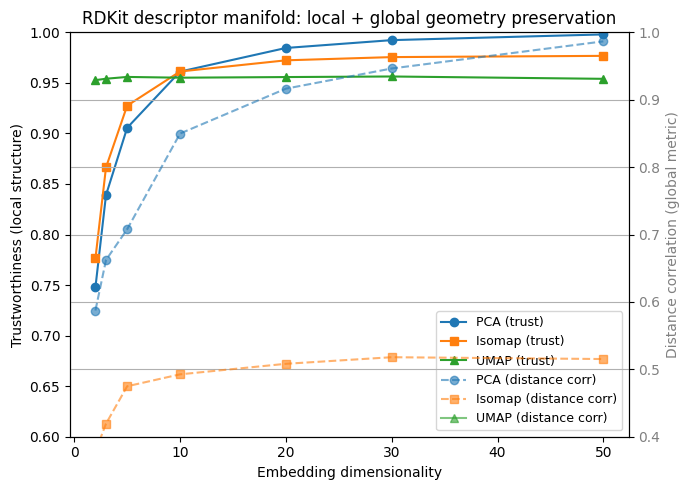

d= 2 | PCA: trust=0.748, corr=0.587 | Isomap: trust=0.776, corr=0.378 | UMAP: trust=0.953, corr=0.219
d= 3 | PCA: trust=0.839, corr=0.662 | Isomap: trust=0.866, corr=0.419 | UMAP: trust=0.954, corr=0.262
d= 5 | PCA: trust=0.906, corr=0.708 | Isomap: trust=0.927, corr=0.475 | UMAP: trust=0.956, corr=0.242
d=10 | PCA: trust=0.961, corr=0.850 | Isomap: trust=0.961, corr=0.493 | UMAP: trust=0.955, corr=0.226
d=20 | PCA: trust=0.985, corr=0.916 | Isomap: trust=0.972, corr=0.508 | UMAP: trust=0.956, corr=0.235
d=30 | PCA: trust=0.992, corr=0.946 | Isomap: trust=0.976, corr=0.518 | UMAP: trust=0.956, corr=0.241
d=50 | PCA: trust=0.998, corr=0.987 | Isomap: trust=0.977, corr=0.515 | UMAP: trust=0.954, corr=0.237


In [9]:
# =============================================================
# RDKit descriptor manifold: local + global geometry analysis
# =============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, trustworthiness
import umap
from sklearn.metrics import pairwise_distances
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler

# -------------------------------------------------------------
# 1️⃣  Preprocess descriptors
# -------------------------------------------------------------

X_rd = data_matrix.copy()
X = StandardScaler().fit_transform(X_rd)

# Dimensionalities to test
dims = [2, 3, 5, 10, 20, 30, 50]

# Results
trust_pca, trust_iso, trust_umap = [], [], []
corr_pca,  corr_iso,  corr_umap  = [], [], []

# Random subset for distance correlation (faster)
subset = np.random.choice(X.shape[0], size=1000, replace=False)
D_orig = pairwise_distances(X[subset], metric="euclidean")

# -------------------------------------------------------------
# 2️⃣  Evaluate across methods
# -------------------------------------------------------------
for d in dims:
    print(f"→ Evaluating {d}-D embeddings")

    # --- PCA ---
    pca = PCA(n_components=d, random_state=0)
    coords_pca = pca.fit_transform(X)
    trust_pca.append(trustworthiness(X, coords_pca, n_neighbors=30))
    D_pca = pairwise_distances(coords_pca[subset])
    corr_pca.append(spearmanr(D_orig.ravel(), D_pca.ravel()).correlation)

    # --- Isomap ---
    iso = Isomap(n_neighbors=40, n_components=d, metric="cosine")
    coords_iso = iso.fit_transform(X)
    trust_iso.append(trustworthiness(X, coords_iso, n_neighbors=30))
    D_iso = pairwise_distances(coords_iso[subset])
    corr_iso.append(spearmanr(D_orig.ravel(), D_iso.ravel()).correlation)

    # --- UMAP ---
    uma = umap.UMAP(
        n_neighbors=40, n_components=d, min_dist=0.1,
        metric="cosine", random_state=0
    )
    coords_uma = uma.fit_transform(X)
    trust_umap.append(trustworthiness(X, coords_uma, n_neighbors=30))
    D_uma = pairwise_distances(coords_uma[subset])
    corr_umap.append(spearmanr(D_orig.ravel(), D_uma.ravel()).correlation)

# -------------------------------------------------------------
# 3️⃣  Plot combined results
# -------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(7,5))

# Left y-axis: Trustworthiness
ax1.plot(dims, trust_pca, 'o-', label='PCA (trust)', color='C0')
ax1.plot(dims, trust_iso, 's-', label='Isomap (trust)', color='C1')
ax1.plot(dims, trust_umap, '^-', label='UMAP (trust)', color='C2')
ax1.set_xlabel("Embedding dimensionality")
ax1.set_ylabel("Trustworthiness (local structure)", color='k')
ax1.tick_params(axis='y', labelcolor='k')
ax1.set_ylim(0.6, 1.0)

# Right y-axis: Distance correlation
ax2 = ax1.twinx()
ax2.plot(dims, corr_pca, 'o--', label='PCA (distance corr)', color='C0', alpha=0.6)
ax2.plot(dims, corr_iso, 's--', label='Isomap (distance corr)', color='C1', alpha=0.6)
ax2.plot(dims, corr_umap, '^-', label='UMAP (distance corr)', color='C2', alpha=0.6)
ax2.set_ylabel("Distance correlation (global metric)", color='gray')
ax2.tick_params(axis='y', labelcolor='gray')
ax2.set_ylim(0.4, 1.0)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=9)

plt.title("RDKit descriptor manifold: local + global geometry preservation")
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 4️⃣  Print numeric summary
# -------------------------------------------------------------
for d, tp, ti, tu, cp, ci, cu in zip(dims, trust_pca, trust_iso, trust_umap, corr_pca, corr_iso, corr_umap):
    print(f"d={d:>2d} | PCA: trust={tp:.3f}, corr={cp:.3f} | "
          f"Isomap: trust={ti:.3f}, corr={ci:.3f} | "
          f"UMAP: trust={tu:.3f}, corr={cu:.3f}")


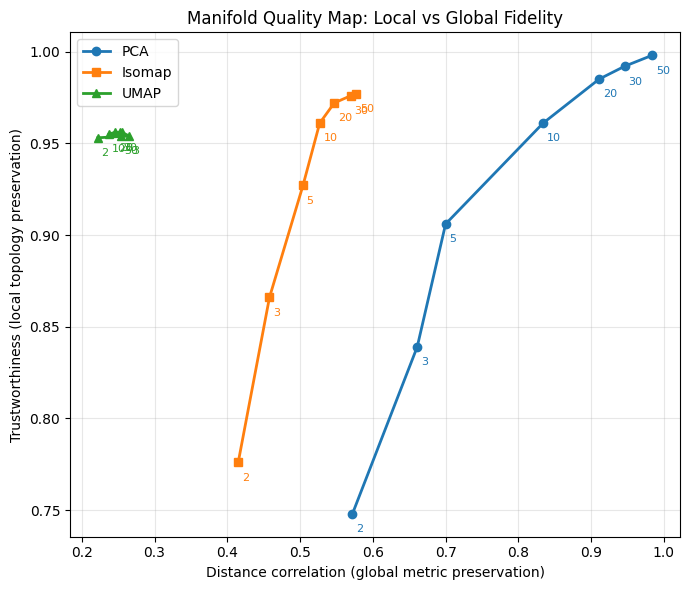

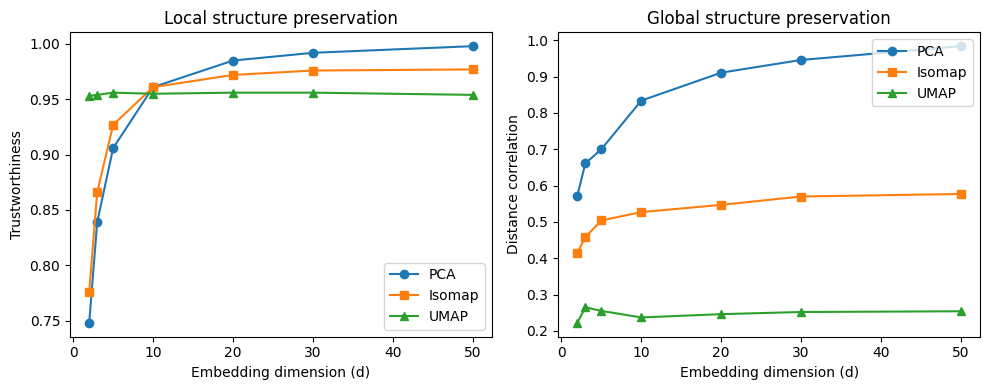

In [42]:
# =============================================================
#  Trustworthiness vs Distance Correlation across methods
# =============================================================
import numpy as np
import matplotlib.pyplot as plt

# Example results from your table:
dims = np.array([2, 3, 5, 10, 20, 30, 50])
trust_pca   = np.array([0.748, 0.839, 0.906, 0.961, 0.985, 0.992, 0.998])
corr_pca    = np.array([0.572, 0.661, 0.700, 0.834, 0.911, 0.946, 0.984])

trust_iso   = np.array([0.776, 0.866, 0.927, 0.961, 0.972, 0.976, 0.977])
corr_iso    = np.array([0.415, 0.458, 0.504, 0.527, 0.547, 0.570, 0.577])

trust_umap  = np.array([0.953, 0.954, 0.956, 0.955, 0.956, 0.956, 0.954])
corr_umap   = np.array([0.222, 0.265, 0.255, 0.237, 0.246, 0.252, 0.254])

# --- Plot tradeoff map ---
plt.figure(figsize=(7,6))
plt.plot(corr_pca, trust_pca, 'o-', label='PCA', lw=2)
plt.plot(corr_iso, trust_iso, 's-', label='Isomap', lw=2)
plt.plot(corr_umap, trust_umap, '^-', label='UMAP', lw=2)

for i, d in enumerate(dims):
    plt.text(corr_pca[i]+0.005, trust_pca[i]-0.01, str(d), color='tab:blue', fontsize=8)
    plt.text(corr_iso[i]+0.005, trust_iso[i]-0.01, str(d), color='tab:orange', fontsize=8)
    plt.text(corr_umap[i]+0.005, trust_umap[i]-0.01, str(d), color='tab:green', fontsize=8)

plt.xlabel("Distance correlation (global metric preservation)")
plt.ylabel("Trustworthiness (local topology preservation)")
plt.title("Manifold Quality Map: Local vs Global Fidelity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- Optional: 1D profiles to show how each metric evolves ---
fig, ax = plt.subplots(1, 2, figsize=(10,4), sharex=True)
ax[0].plot(dims, trust_pca, 'o-', label='PCA')
ax[0].plot(dims, trust_iso, 's-', label='Isomap')
ax[0].plot(dims, trust_umap, '^-', label='UMAP')
ax[0].set_xlabel("Embedding dimension (d)")
ax[0].set_ylabel("Trustworthiness")
ax[0].set_title("Local structure preservation")
ax[0].legend()

ax[1].plot(dims, corr_pca, 'o-', label='PCA')
ax[1].plot(dims, corr_iso, 's-', label='Isomap')
ax[1].plot(dims, corr_umap, '^-', label='UMAP')
ax[1].set_xlabel("Embedding dimension (d)")
ax[1].set_ylabel("Distance correlation")
ax[1].set_title("Global structure preservation")
ax[1].legend()

plt.tight_layout()
plt.show()


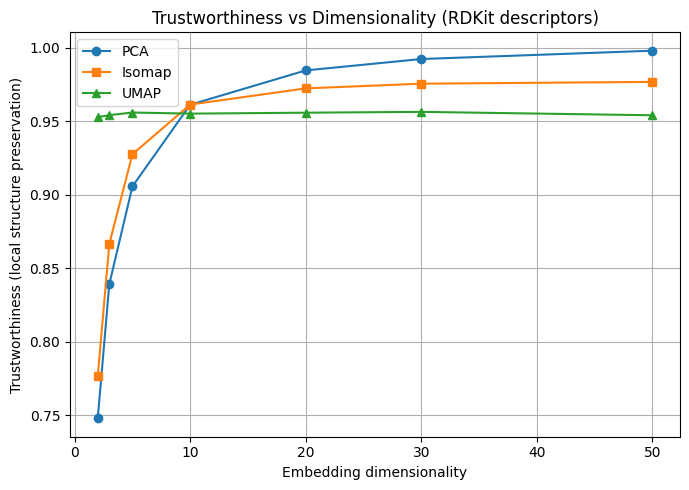

d= 2 | PCA=0.7477 | Isomap=0.7763 | UMAP=0.9527
d= 3 | PCA=0.8390 | Isomap=0.8664 | UMAP=0.9541
d= 5 | PCA=0.9056 | Isomap=0.9275 | UMAP=0.9559
d=10 | PCA=0.9612 | Isomap=0.9613 | UMAP=0.9551
d=20 | PCA=0.9845 | Isomap=0.9723 | UMAP=0.9558
d=30 | PCA=0.9923 | Isomap=0.9755 | UMAP=0.9563
d=50 | PCA=0.9979 | Isomap=0.9767 | UMAP=0.9540


In [43]:
# =============================================================
# Trustworthiness vs Dimensionality on RDKit descriptor space
# =============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, trustworthiness
import umap
from sklearn.preprocessing import StandardScaler

# -------------------------------------------------------------
# 1️⃣  Preprocess descriptors
# -------------------------------------------------------------
X = StandardScaler().fit_transform(X_rd)

# Dimensionalities to test
dims = [2, 3, 5, 10, 20, 30, 50]

# Storage
trust_pca, trust_iso, trust_umap = [], [], []

# -------------------------------------------------------------
# 2️⃣  Evaluate across methods
# -------------------------------------------------------------
for d in dims:
    # --- PCA ---
    pca = PCA(n_components=d, random_state=0)
    coords_pca = pca.fit_transform(X)
    trust_pca.append(trustworthiness(X, coords_pca, n_neighbors=30))

    # --- Isomap ---
    iso = Isomap(n_neighbors=40, n_components=d, metric="cosine")
    coords_iso = iso.fit_transform(X)
    trust_iso.append(trustworthiness(X, coords_iso, n_neighbors=30))

    # --- UMAP ---
    uma = umap.UMAP(
        n_neighbors=40, n_components=d, min_dist=0.1,
        metric="cosine", random_state=0
    )
    coords_uma = uma.fit_transform(X)
    trust_umap.append(trustworthiness(X, coords_uma, n_neighbors=30))

# -------------------------------------------------------------
# 3️⃣  Plot results
# -------------------------------------------------------------
plt.figure(figsize=(7,5))
plt.plot(dims, trust_pca, 'o-', label='PCA')
plt.plot(dims, trust_iso, 's-', label='Isomap')
plt.plot(dims, trust_umap, '^-', label='UMAP')
plt.xlabel("Embedding dimensionality")
plt.ylabel("Trustworthiness (local structure preservation)")
plt.title("Trustworthiness vs Dimensionality (RDKit descriptors)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 4️⃣  Print numeric summary
# -------------------------------------------------------------
for d, tp, ti, tu in zip(dims, trust_pca, trust_iso, trust_umap):
    print(f"d={d:>2d} | PCA={tp:.4f} | Isomap={ti:.4f} | UMAP={tu:.4f}")


Mean normalized distance ratio (Isomap / Raw): 1.910
Std of ratio: 1.375
Nonlinearity index (log-variance): 0.804


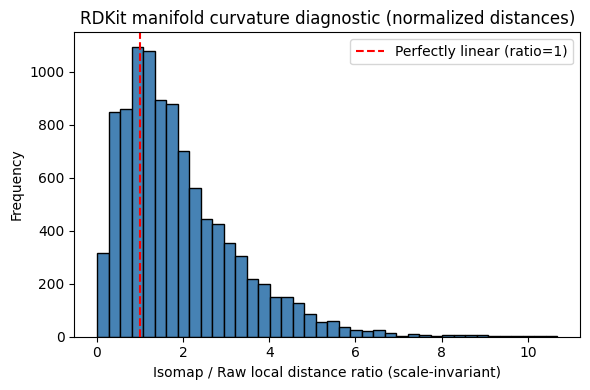

In [46]:
# =============================================================
# Scale-invariant geometric warping diagnostic
# =============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import Isomap
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler, minmax_scale

# 1️⃣ Standardize descriptors
X = StandardScaler().fit_transform(X_rd)

# 2️⃣ Compute Isomap embedding
iso = Isomap(n_neighbors=40, n_components=3, metric='cosine')
X_iso = iso.fit_transform(X)

# 3️⃣ Sample subset to avoid N^2 scaling
subset = np.random.choice(X.shape[0], size=1000, replace=False)
X_sub = X[subset]
X_iso_sub = X_iso[subset]

# 4️⃣ Compute pairwise distances
D_raw = pairwise_distances(X_sub)
D_iso = pairwise_distances(X_iso_sub)

# 5️⃣ Normalize distances to [0,1] to remove scale bias
D_raw_norm = minmax_scale(D_raw.ravel()).reshape(D_raw.shape)
D_iso_norm = minmax_scale(D_iso.ravel()).reshape(D_iso.shape)

# 6️⃣ Compute local neighborhood distortion (scale-invariant)
k = 10  # local neighborhood size
idx = np.argsort(D_raw_norm, axis=1)[:, 1:k+1]
ratios = []
for i in range(D_raw.shape[0]):
    orig_d = D_raw_norm[i, idx[i]]
    iso_d  = D_iso_norm[i, idx[i]]
    ratios.extend(iso_d / (orig_d + 1e-9))
ratios = np.array(ratios)

# 7️⃣ Compute curvature metrics
mean_ratio = np.mean(ratios)
std_ratio = np.std(ratios)
nonlinearity_index = np.std(np.log(ratios + 1e-9))

print(f"Mean normalized distance ratio (Isomap / Raw): {mean_ratio:.3f}")
print(f"Std of ratio: {std_ratio:.3f}")
print(f"Nonlinearity index (log-variance): {nonlinearity_index:.3f}")

# 8️⃣ Plot results
plt.figure(figsize=(6,4))
plt.hist(ratios, bins=40, color='steelblue', edgecolor='k')
plt.axvline(1.0, color='r', linestyle='--', label='Perfectly linear (ratio=1)')
plt.xlabel("Isomap / Raw local distance ratio (scale-invariant)")
plt.ylabel("Frequency")
plt.title("RDKit manifold curvature diagnostic (normalized distances)")
plt.legend()
plt.tight_layout()
plt.show()



=== Rank-normalized local distortion & global correlations ===
k=15 | Raw↔Geo: mean=0.72, std=0.26, corr=0.850 || Geo↔Iso: mean=2.98, std=2.52, corr=0.834 || Raw↔Iso corr=0.713
k=20 | Raw↔Geo: mean=0.76, std=0.24, corr=0.882 || Geo↔Iso: mean=2.90, std=2.37, corr=0.836 || Raw↔Iso corr=0.726
k=30 | Raw↔Geo: mean=0.82, std=0.22, corr=0.925 || Geo↔Iso: mean=2.95, std=2.53, corr=0.841 || Raw↔Iso corr=0.763
k=40 | Raw↔Geo: mean=0.86, std=0.20, corr=0.942 || Geo↔Iso: mean=2.82, std=2.40, corr=0.840 || Raw↔Iso corr=0.784
k=50 | Raw↔Geo: mean=0.88, std=0.18, corr=0.950 || Geo↔Iso: mean=2.76, std=2.31, corr=0.839 || Raw↔Iso corr=0.795
k=60 | Raw↔Geo: mean=0.90, std=0.17, corr=0.956 || Geo↔Iso: mean=2.83, std=2.39, corr=0.836 || Raw↔Iso corr=0.799
k=80 | Raw↔Geo: mean=0.92, std=0.15, corr=0.963 || Geo↔Iso: mean=2.79, std=2.32, corr=0.833 || Raw↔Iso corr=0.810


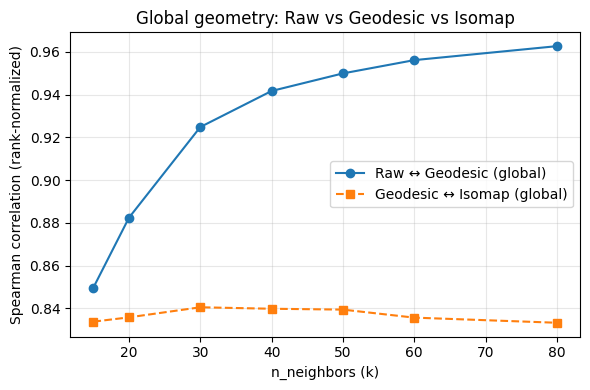

In [47]:
# =============================================================
# Robust curvature & fidelity diagnostics for RDKit manifold
# - Compare Raw Euclidean vs Geodesic vs Isomap embedding
# - Rank-normalized distances (scale-invariant, outlier-robust)
# - Sweep n_neighbors to see stability
# =============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import shortest_path
from sklearn.metrics import pairwise_distances
from sklearn.manifold import Isomap
from scipy.stats import spearmanr

# ---------- helpers ----------
def rank_normalize(D):
    """Return distance matrix with entries replaced by percentile ranks in [0,1]."""
    r = D.ravel().argsort().argsort().astype(float)
    r /= (r.size - 1 + 1e-9)
    return r.reshape(D.shape)

def local_ratio_stats(D_ref, D_alt, k=10):
    """Ratio of alt/ref within k-NN of REF (scale-invariant if inputs are normalized)."""
    idx = np.argsort(D_ref, axis=1)[:, 1:k+1]
    ratios = []
    for i in range(D_ref.shape[0]):
        ref = D_ref[i, idx[i]]
        alt = D_alt[i, idx[i]]
        ratios.extend(alt / (ref + 1e-9))
    ratios = np.array(ratios)
    return ratios.mean(), ratios.std(), np.std(np.log(ratios + 1e-12)), ratios

def geo_matrix(X, n_neighbors=40, metric='euclidean'):
    G = kneighbors_graph(X, n_neighbors=n_neighbors, mode='distance', metric=metric, include_self=False)
    return shortest_path(G, directed=False, unweighted=False)  # geodesic (shortest paths)

# ---------- data ----------
# X_rd: (N,D) RDKit descriptor matrix
X = StandardScaler().fit_transform(X_rd)

# (optional but recommended) denoise/sphere with PCA before geodesics & Isomap
pca = PCA(n_components=50, random_state=0)
X50 = pca.fit_transform(X)

# Subsample to keep O(N^2) distances tractable
N = X50.shape[0]
subset = np.random.choice(N, size=min(1200, N), replace=False)
Xs = X50[subset]

# ---------- sweep neighbors ----------
ks = [15, 20, 30, 40, 50, 60, 80]
results = []

for k in ks:
    # Geodesic distances (on PCA50 space)
    D_geo = geo_matrix(Xs, n_neighbors=k, metric='euclidean')

    # Raw Euclidean distances
    D_raw = pairwise_distances(Xs, metric='euclidean')

    # Isomap embedding (fit on the same subset & k)
    iso = Isomap(n_neighbors=k, n_components=3, metric='euclidean')
    X_iso = iso.fit_transform(Xs)
    D_iso = pairwise_distances(X_iso, metric='euclidean')

    # Rank-normalize all three to remove scale/outlier effects
    D_raw_r = rank_normalize(D_raw)
    D_geo_r = rank_normalize(D_geo)
    D_iso_r = rank_normalize(D_iso)

    # (A) True nonlinearity: how different is Raw vs Geodesic?
    mean_rg, std_rg, logvar_rg, _ = local_ratio_stats(D_raw_r, D_geo_r, k=10)
    corr_rg = spearmanr(D_raw_r.ravel(), D_geo_r.ravel()).correlation

    # (B) Isomap fidelity: how well does embedding recover Geodesic?
    mean_gi, std_gi, logvar_gi, _ = local_ratio_stats(D_geo_r, D_iso_r, k=10)
    corr_gi = spearmanr(D_geo_r.ravel(), D_iso_r.ravel()).correlation

    # (C) Sanity: Raw vs Isomap directly (not what Isomap optimizes)
    mean_ri, std_ri, logvar_ri, _ = local_ratio_stats(D_raw_r, D_iso_r, k=10)
    corr_ri = spearmanr(D_raw_r.ravel(), D_iso_r.ravel()).correlation

    results.append({
        "k": k,
        "Raw↔Geo_mean": mean_rg, "Raw↔Geo_std": std_rg, "Raw↔Geo_logvar": logvar_rg, "Raw↔Geo_corr": corr_rg,
        "Geo↔Iso_mean": mean_gi, "Geo↔Iso_std": std_gi, "Geo↔Iso_logvar": logvar_gi, "Geo↔Iso_corr": corr_gi,
        "Raw↔Iso_mean": mean_ri, "Raw↔Iso_std": std_ri, "Raw↔Iso_logvar": logvar_ri, "Raw↔Iso_corr": corr_ri,
    })

# ---------- print summary ----------
print("\n=== Rank-normalized local distortion & global correlations ===")
for r in results:
    print(f"k={r['k']:>2} | Raw↔Geo: mean={r['Raw↔Geo_mean']:.2f}, std={r['Raw↔Geo_std']:.2f}, "
          f"corr={r['Raw↔Geo_corr']:.3f} || Geo↔Iso: mean={r['Geo↔Iso_mean']:.2f}, "
          f"std={r['Geo↔Iso_std']:.2f}, corr={r['Geo↔Iso_corr']:.3f} || Raw↔Iso corr={r['Raw↔Iso_corr']:.3f}")

# ---------- quick plots ----------
ks_arr = np.array(ks)
corr_rg = np.array([r["Raw↔Geo_corr"] for r in results])
corr_gi = np.array([r["Geo↔Iso_corr"] for r in results])

plt.figure(figsize=(6,4))
plt.plot(ks_arr, corr_rg, 'o-', label='Raw ↔ Geodesic (global)')
plt.plot(ks_arr, corr_gi, 's--', label='Geodesic ↔ Isomap (global)')
plt.xlabel("n_neighbors (k)")
plt.ylabel("Spearman correlation (rank-normalized)")
plt.title("Global geometry: Raw vs Geodesic vs Isomap")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Mean distortion: 0.361, std: 0.000
Top 1% high-curvature points: 0.361


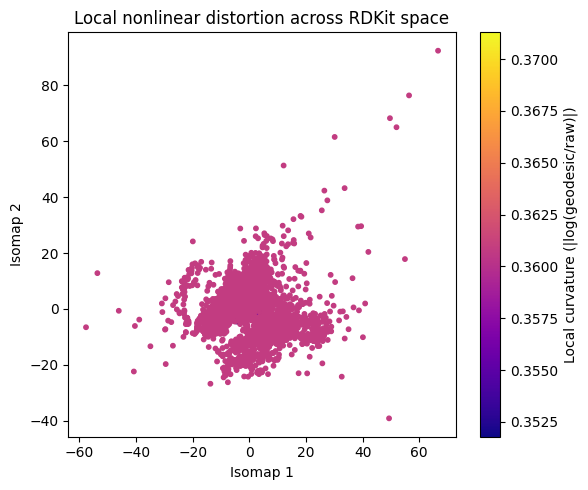

In [48]:
# =============================================================
# Local distortion map: where is the RDKit space nonlinear?
# =============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import shortest_path
from sklearn.metrics import pairwise_distances
from sklearn.manifold import Isomap

# ---------- setup ----------
X = StandardScaler().fit_transform(X_rd)
pca = PCA(n_components=50, random_state=0)
X50 = pca.fit_transform(X)

n_neighbors = 40  # same as in your analysis

# ---------- compute geodesic vs raw distances ----------
G = kneighbors_graph(X50, n_neighbors=n_neighbors, mode='distance', include_self=False)
D_geo = shortest_path(G, directed=False, unweighted=False)
D_raw = pairwise_distances(X50, metric='euclidean')

# normalize (scale invariant)
D_geo /= np.max(D_geo)
D_raw /= np.max(D_raw)

# ---------- compute local curvature per point ----------
# local distortion = mean |log(D_geo / D_raw)| over nearest neighbors
idx = np.argsort(D_raw, axis=1)[:, 1:n_neighbors+1]
local_distortion = np.zeros(X50.shape[0])
for i in range(X50.shape[0]):
    r = D_raw[i, idx[i]]
    g = D_geo[i, idx[i]]
    ratios = np.log((g + 1e-9) / (r + 1e-9))
    local_distortion[i] = np.mean(np.abs(ratios))

print(f"Mean distortion: {np.mean(local_distortion):.3f}, std: {np.std(local_distortion):.3f}")
print(f"Top 1% high-curvature points: {np.percentile(local_distortion, 99):.3f}")

# ---------- visualize ----------
iso = Isomap(n_neighbors=n_neighbors, n_components=2)
X_iso = iso.fit_transform(X50)

plt.figure(figsize=(6,5))
plt.scatter(X_iso[:,0], X_iso[:,1], c=local_distortion, cmap='plasma', s=10)
plt.colorbar(label='Local curvature (|log(geodesic/raw)|)')
plt.title('Local nonlinear distortion across RDKit space')
plt.xlabel('Isomap 1')
plt.ylabel('Isomap 2')
plt.tight_layout()
plt.show()


In [49]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from rdkit.Chem import Descriptors
from scipy.stats import ks_2samp

# --- 1) PCA embedding (20–30D) ---
X_std = StandardScaler().fit_transform(X_rd)
pca = PCA(n_components=30, random_state=0)
X_pca = pca.fit_transform(X_std)

# --- 2) Samplers ---
def farthest_point_sampling(X, K, start=0):
    sel = [start]
    dist = np.full(X.shape[0], np.inf)
    for _ in range(K-1):
        d = np.linalg.norm(X - X[sel[-1]], axis=1)
        dist = np.minimum(dist, d)
        sel.append(np.argmax(dist))
    return np.array(sel)

def kmeans_medoids(X, K, seed=0):
    km = KMeans(n_clusters=K, random_state=seed, n_init="auto").fit(X)
    from sklearn.metrics import pairwise_distances_argmin_min
    idx, _ = pairwise_distances_argmin_min(km.cluster_centers_, X)
    return idx

K = 300  # number of molecules to pick
idx_pca = farthest_point_sampling(X_pca, K)  # or kmeans_medoids(X_pca, K)

# --- 3) Evaluate coverage in original standardized space ---
D = pairwise_distances(X_std, X_std[idx_pca])
minD = np.min(D, axis=1)
coverage_mean, coverage_sd = np.mean(minD), np.std(minD)
print(f"Coverage (mean±SD): {coverage_mean:.3f} ± {coverage_sd:.3f}")

# --- 4) Evaluate property KS (representativeness) ---
props = {
    "MolWt":  np.array([Descriptors.MolWt(m) for m in mols]),
    "logP":   np.array([Descriptors.MolLogP(m) for m in mols]),
    "TPSA":   np.array([Descriptors.TPSA(m) for m in mols]),
}
def ks_table(idx):
    return {k: ks_2samp(v, v[idx]).statistic for k, v in props.items()}
ks_results = ks_table(idx_pca)
print("KS (subset vs full):", {k: round(v,3) for k,v in ks_results.items()})

# --- 5) (Optional) Diversity booster from curvature tail, then prune ---
# If you computed `local_distortion` earlier:
# pick top-M high-curvature points and union with PCA picks; prune by k-center in PCA space
# M = 50
# cand = np.unique(np.concatenate([idx_pca, np.argsort(local_distortion)[-M:]]))
# idx_final = farthest_point_sampling(X_pca[cand], K)
# idx_final = cand[idx_final]
# ...then re-run coverage/KS on idx_final


Coverage (mean±SD): 8.608 ± 3.110
KS (subset vs full): {'MolWt': np.float64(0.374), 'logP': np.float64(0.326), 'TPSA': np.float64(0.444)}


In [8]:
# ============================================================
# PCA vs UMAP comparison for RDKit descriptors
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import trustworthiness
from sklearn.metrics import pairwise_distances
from scipy.stats import spearmanr
import umap

# --- Standardize ---
X_std = StandardScaler().fit_transform(X_rd)

# --- Reduce with PCA and UMAP ---
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_std)

umap_model = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=0)
X_umap = umap_model.fit_transform(X_std)

# --- Compute metrics ---
# global structure: Spearman correlation of pairwise distances
D_raw = pairwise_distances(X_std)
D_pca = pairwise_distances(X_pca)
D_umap = pairwise_distances(X_umap)

corr_pca = spearmanr(D_raw.ravel(), D_pca.ravel()).correlation
corr_umap = spearmanr(D_raw.ravel(), D_umap.ravel()).correlation

# local structure: trustworthiness
trust_pca = trustworthiness(X_std, X_pca, n_neighbors=15)
trust_umap = trustworthiness(X_std, X_umap, n_neighbors=15)

print(f"=== Geometry Fidelity (RDKit descriptors) ===")
print(f"PCA : trust={trust_pca:.3f}, distance_corr={corr_pca:.3f}")
print(f"UMAP: trust={trust_umap:.3f}, distance_corr={corr_umap:.3f}")

# --- Visualize embeddings ---
fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].scatter(X_pca[:,0], X_pca[:,1], s=8, alpha=0.5, color='steelblue')
ax[0].set_title(f"PCA embedding\ntrust={trust_pca:.3f}, corr={corr_pca:.3f}")
ax[0].set_xlabel("PC1"); ax[0].set_ylabel("PC2")

ax[1].scatter(X_umap[:,0], X_umap[:,1], s=8, alpha=0.5, color='darkorange')
ax[1].set_title(f"UMAP embedding\ntrust={trust_umap:.3f}, corr={corr_umap:.3f}")
ax[1].set_xlabel("UMAP 1"); ax[1].set_ylabel("UMAP 2")

plt.suptitle("PCA vs UMAP on RDKit descriptors")
plt.tight_layout()
plt.show()

# --- Optional: neighborhood distortion map ---
# Compare how often neighbors change between spaces
def neighbor_overlap(X1, X2, k=15):
    nn1 = np.argsort(pairwise_distances(X1), axis=1)[:,1:k+1]
    nn2 = np.argsort(pairwise_distances(X2), axis=1)[:,1:k+1]
    overlap = [len(set(a).intersection(b))/k for a,b in zip(nn1, nn2)]
    return np.array(overlap)

overlap_pca = neighbor_overlap(X_std, X_pca)
overlap_umap = neighbor_overlap(X_std, X_umap)

plt.figure(figsize=(6,4))
plt.hist(overlap_pca, bins=30, alpha=0.6, label='PCA', color='steelblue')
plt.hist(overlap_umap, bins=30, alpha=0.6, label='UMAP', color='darkorange')
plt.xlabel("Neighbor overlap fraction (w.r.t. original 15-NN)")
plt.ylabel("Count")
plt.title("Local neighborhood fidelity")
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'X_rd' is not defined

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
import umap

# --- Standardize and embed ---
X_std = StandardScaler().fit_transform(X_rd)

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_std)

umap_model = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=0)
X_umap = umap_model.fit_transform(X_std)

# --- Compare distance distortions ---
def distance_distortion(X, X_emb, k=10):
    D_orig = pairwise_distances(X)
    D_emb  = pairwise_distances(X_emb)
    # For each point, compare how distances to its nearest neighbors changed
    idx = np.argsort(D_orig, axis=1)[:, 1:k+1]
    ratios = []
    for i in range(X.shape[0]):
        r = D_orig[i, idx[i]]
        e = D_emb[i, idx[i]]
        ratios.extend(np.log10((e + 1e-9) / (r + 1e-9)))
    return np.array(ratios)

dist_pca = distance_distortion(X_std, X_pca)
dist_umap = distance_distortion(X_std, X_umap)

# --- Plot histograms of log-distance distortion ---
plt.figure(figsize=(7,4))
plt.hist(dist_pca, bins=50, alpha=0.6, label='PCA', color='steelblue')
plt.hist(dist_umap, bins=50, alpha=0.6, label='UMAP', color='darkorange')
plt.axvline(0, color='k', linestyle='--')
plt.xlabel('log10(embedded_distance / original_distance)')
plt.ylabel('Count')
plt.title('Local distance distortion (k=10)')
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'X_rd' is not defined

/Users/briandepasquale/Documents/GitHub/odorant_sampling/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


=== Geometry fidelity (k-NN and global distances) ===
PCA   : trust=0.989  | dist_corr=0.921
Isomap: trust=0.993  | dist_corr=0.833
UMAP  : trust=0.966 | dist_corr=0.336


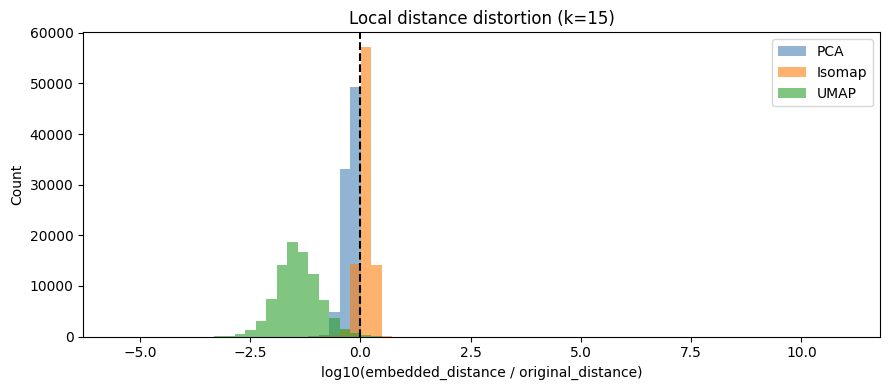

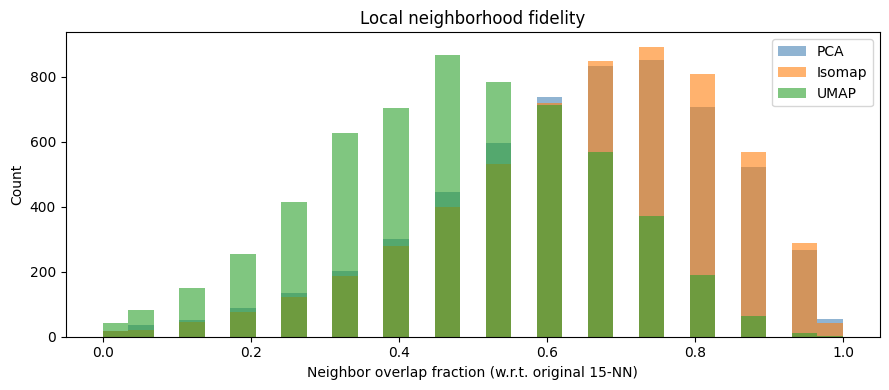

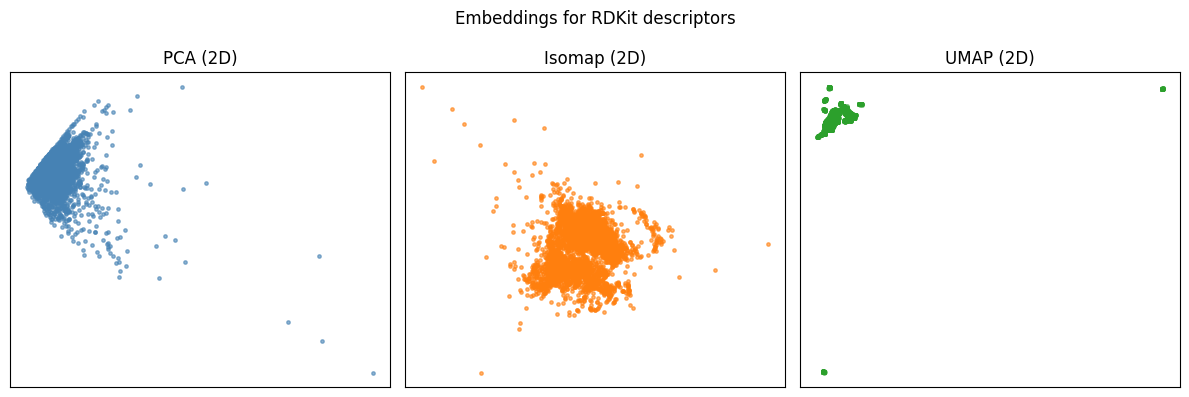

In [10]:
# ============================================================
# PCA vs Isomap vs UMAP: geometry fidelity on RDKit descriptors
#   - Local distance distortion: log10(d_embedded / d_original)
#   - Neighbor overlap with original k-NN
#   - Trustworthiness + global distance correlation
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, trustworthiness
from sklearn.metrics import pairwise_distances
from scipy.stats import spearmanr
import umap

# ------------------------------
# Inputs
#   X_rd: (N, D) RDKit descriptor matrix
# ------------------------------
assert 'X_rd' in globals(), "X_rd (N x D RDKit descriptors) must exist"

# --- params ---
k_nn_eval = 15            # neighborhood size for trustworthiness & overlap
n_neighbors_iso = 40      # Isomap graph neighbors
n_neighbors_umap = 30     # UMAP neighbors
min_dist_umap = 0.1
emb_dim = 20               # 2D for fair visual comparison
subset_n = None           # e.g. 3000 to speed up; or None for all

# --- standardize & optional subset ---
X_std_all = StandardScaler().fit_transform(X_rd)
if subset_n is not None and subset_n < X_std_all.shape[0]:
    rng = np.random.default_rng(0)
    keep = rng.choice(X_std_all.shape[0], size=subset_n, replace=False)
    X_std = X_std_all[keep]
else:
    keep = np.arange(X_std_all.shape[0])
    X_std = X_std_all

# --- embeddings ---
pca = PCA(n_components=emb_dim, random_state=0)
X_pca = pca.fit_transform(X_std)

iso = Isomap(n_neighbors=n_neighbors_iso, n_components=emb_dim, metric='euclidean')
X_iso = iso.fit_transform(X_std)

umap_model = umap.UMAP(n_neighbors=n_neighbors_umap, min_dist=min_dist_umap,
                       n_components=emb_dim, random_state=0, metric='euclidean')
X_umap = umap_model.fit_transform(X_std)

# --- pairwise distances (for metrics) ---
D_raw  = pairwise_distances(X_std)
D_pca  = pairwise_distances(X_pca)
D_iso  = pairwise_distances(X_iso)
D_umap = pairwise_distances(X_umap)

# --- metrics: global & local ---
def global_corr(D1, D2):
    return spearmanr(D1.ravel(), D2.ravel()).correlation

corr_pca  = global_corr(D_raw, D_pca)
corr_iso  = global_corr(D_raw, D_iso)
corr_umap = global_corr(D_raw, D_umap)

trust_pca  = trustworthiness(X_std, X_pca,  n_neighbors=k_nn_eval)
trust_iso  = trustworthiness(X_std, X_iso,  n_neighbors=k_nn_eval)
trust_umap = trustworthiness(X_std, X_umap, n_neighbors=k_nn_eval)

print("=== Geometry fidelity (k-NN and global distances) ===")
print(f"PCA   : trust={trust_pca:.3f}  | dist_corr={corr_pca:.3f}")
print(f"Isomap: trust={trust_iso:.3f}  | dist_corr={corr_iso:.3f}")
print(f"UMAP  : trust={trust_umap:.3f} | dist_corr={corr_umap:.3f}")

# --- local distance distortion histograms ---
def local_distortion_hist(D_orig, D_emb, k=10):
    idx = np.argsort(D_orig, axis=1)[:, 1:k+1]  # neighbors in original space
    vals = []
    for i in range(D_orig.shape[0]):
        r = D_orig[i, idx[i]]
        e = D_emb[i,  idx[i]]
        vals.extend(np.log10((e + 1e-12) / (r + 1e-12)))
    return np.array(vals)

dist_pca  = local_distortion_hist(D_raw, D_pca,  k=k_nn_eval)
dist_iso  = local_distortion_hist(D_raw, D_iso,  k=k_nn_eval)
dist_umap = local_distortion_hist(D_raw, D_umap, k=k_nn_eval)

plt.figure(figsize=(9,4))
bins = np.linspace(min(dist_umap.min(), dist_iso.min(), dist_pca.min()),
                   max(dist_umap.max(), dist_iso.max(), dist_pca.max()), 70)
plt.hist(dist_pca,  bins=bins, alpha=0.6, label='PCA',   color='steelblue')
plt.hist(dist_iso,  bins=bins, alpha=0.6, label='Isomap',color='tab:orange')
plt.hist(dist_umap, bins=bins, alpha=0.6, label='UMAP',  color='tab:green')
plt.axvline(0, color='k', ls='--')
plt.xlabel('log10(embedded_distance / original_distance)')
plt.ylabel('Count')
plt.title(f'Local distance distortion (k={k_nn_eval})')
plt.legend()
plt.tight_layout()
plt.show()

# --- neighbor overlap histogram ---
def neighbor_overlap(X_orig, X_emb, k=15):
    idx_o = np.argsort(pairwise_distances(X_orig), axis=1)[:, 1:k+1]
    idx_e = np.argsort(pairwise_distances(X_emb),  axis=1)[:, 1:k+1]
    ov = [len(set(a).intersection(b))/k for a,b in zip(idx_o, idx_e)]
    return np.array(ov)

ov_pca  = neighbor_overlap(X_std, X_pca,  k=k_nn_eval)
ov_iso  = neighbor_overlap(X_std, X_iso,  k=k_nn_eval)
ov_umap = neighbor_overlap(X_std, X_umap, k=k_nn_eval)

plt.figure(figsize=(9,4))
bins = np.linspace(0,1,30)
plt.hist(ov_pca,  bins=bins, alpha=0.6, label='PCA',   color='steelblue')
plt.hist(ov_iso,  bins=bins, alpha=0.6, label='Isomap',color='tab:orange')
plt.hist(ov_umap, bins=bins, alpha=0.6, label='UMAP',  color='tab:green')
plt.xlabel(f'Neighbor overlap fraction (w.r.t. original {k_nn_eval}-NN)')
plt.ylabel('Count')
plt.title('Local neighborhood fidelity')
plt.legend()
plt.tight_layout()
plt.show()

# --- small scatter viz for context (optional) ---
fig, ax = plt.subplots(1,3, figsize=(12,4))
ax[0].scatter(X_pca[:,0], X_pca[:,1], s=6, alpha=0.6, color='steelblue'); ax[0].set_title("PCA (2D)")
ax[1].scatter(X_iso[:,0], X_iso[:,1], s=6, alpha=0.6, color='tab:orange'); ax[1].set_title("Isomap (2D)")
ax[2].scatter(X_umap[:,0], X_umap[:,1], s=6, alpha=0.6, color='tab:green'); ax[2].set_title("UMAP (2D)")
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.suptitle("Embeddings for RDKit descriptors")
plt.tight_layout(); plt.show()


k=  5 → PCA↔Isomap distance corr = 0.253
k= 10 → PCA↔Isomap distance corr = 0.253
k= 20 → PCA↔Isomap distance corr = 0.253
k= 30 → PCA↔Isomap distance corr = 0.253
k= 50 → PCA↔Isomap distance corr = 0.253
k= 80 → PCA↔Isomap distance corr = 0.253


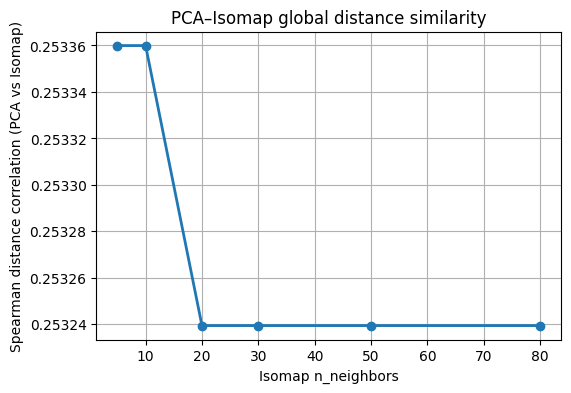

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
from sklearn.metrics import pairwise_distances
from scipy.stats import spearmanr

# --- Load your data ---
# X_rd = your (N, D) descriptor matrix
# Example fallback if you just want to test:
# from sklearn.datasets import make_swiss_roll
# X_rd, _ = make_swiss_roll(2000, noise=0.05)

# --- Step 1: PCA baseline ---
pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_rd)

# --- Step 2: Isomap with different neighborhood sizes ---
neighbor_values = [5, 10, 20, 30, 50, 80]
correlations = []

for k in neighbor_values:
    iso = Isomap(n_neighbors=k, n_components=20)
    X_iso = iso.fit_transform(X_rd)

    # compute pairwise distance matrices
    D_pca = pairwise_distances(X_pca)
    D_iso = pairwise_distances(X_iso)

    # flatten to 1D and compute Spearman correlation
    corr, _ = spearmanr(D_pca.ravel(), D_iso.ravel())
    correlations.append(corr)
    print(f"k={k:3d} → PCA↔Isomap distance corr = {corr:.3f}")

# --- Step 3: Plot correlation curve ---
plt.figure(figsize=(6,4))
plt.plot(neighbor_values, correlations, 'o-', lw=2)
plt.xlabel("Isomap n_neighbors")
plt.ylabel("Spearman distance correlation (PCA vs Isomap)")
plt.title("PCA–Isomap global distance similarity")
plt.grid(True)
plt.show()


In [56]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import Isomap
from scipy.sparse.csgraph import connected_components, shortest_path
from sklearn.metrics import pairwise_distances

for k in [5, 10, 20, 30, 50, 80]:
    # --- Fit Isomap ---
    iso = Isomap(n_neighbors=k, n_components=20)
    X_iso = iso.fit_transform(X_rd)

    # --- Manually rebuild the neighbor graph ---
    nn = NearestNeighbors(n_neighbors=k).fit(X_rd)
    A = nn.kneighbors_graph(X_rd, mode='distance')

    # --- Check connectivity ---
    n_conn, labels = connected_components(A, directed=False)

    # --- Compute geodesic distance matrix ---
    D_geo = shortest_path(A, directed=False, unweighted=False)
    D_geo = np.where(np.isfinite(D_geo), D_geo, np.nan)

    # --- Compare to Euclidean distances in the Isomap embedding ---
    D_iso = pairwise_distances(X_iso)

    # --- Compute stress (normalized squared error) ---
    mask = ~np.isnan(D_geo)
    stress = np.sqrt(np.nanmean((D_geo[mask] - D_iso[mask])**2)) / np.nanmean(D_geo[mask])

    print(f"k={k:<3d} | Connected components: {n_conn:<4d} | Approx stress: {stress:.4f}")


k=5   | Connected components: 16   | Approx stress: 0.0000
k=10  | Connected components: 2    | Approx stress: 0.0000
k=20  | Connected components: 1    | Approx stress: 0.0000
k=30  | Connected components: 1    | Approx stress: 0.0000
k=50  | Connected components: 1    | Approx stress: 0.0000
k=80  | Connected components: 1    | Approx stress: 0.0000


Original shape: (5841, 205)
NaNs remaining: 0 | Infs: 0
=== Geometry fidelity metrics ===
PCA    : trust=0.548 | dist_corr=1.000
Isomap : trust=0.547 | dist_corr=1.000
UMAP   : trust=0.990 | dist_corr=-0.007


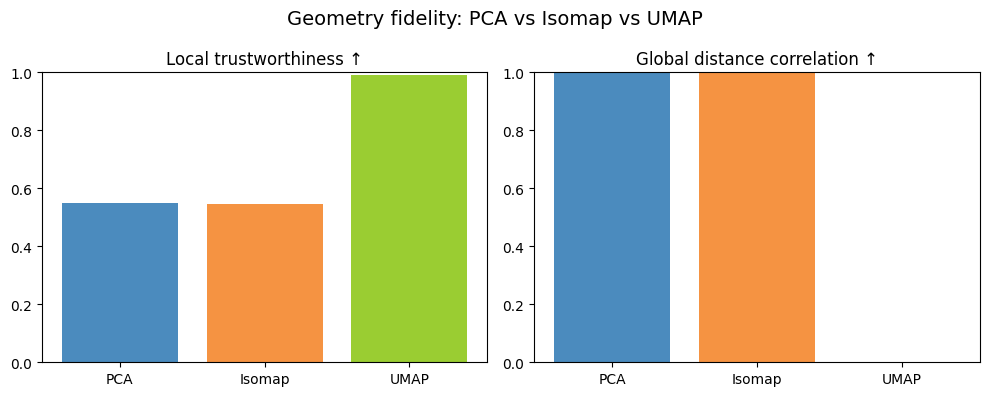

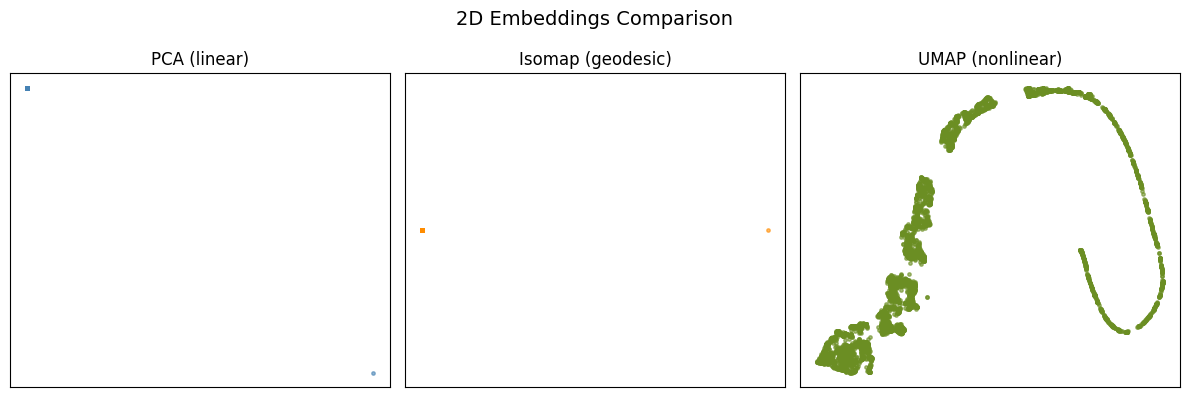

In [59]:
# ===============================================
# Geometry Fidelity Dashboard
# PCA vs Isomap vs UMAP
# ===============================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, trustworthiness
from sklearn.metrics import pairwise_distances
from sklearn.impute import SimpleImputer
import umap

# --- STEP 1: Clean descriptor data -------------------------------
# X_rd = your (N, D) RDKit descriptor array
# Example sanity check:
print(f"Original shape: {X_rd.shape}")

# replace any NaN or inf values
imp = SimpleImputer(strategy="mean")
X_rd = imp.fit_transform(X_rd)
X_rd = np.nan_to_num(X_rd, nan=0.0, posinf=0.0, neginf=0.0)
print(f"NaNs remaining: {np.isnan(X_rd).sum()} | Infs: {np.isinf(X_rd).sum()}")

# --- STEP 2: Fit embeddings -------------------------------------
pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_rd)

iso = Isomap(n_neighbors=20, n_components=20)
X_iso = iso.fit_transform(X_rd)

um = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.1,
    metric="euclidean",
    random_state=42,
    verbose=False
)
X_um = um.fit_transform(X_rd)
X_um = np.nan_to_num(X_um, nan=0.0, posinf=0.0, neginf=0.0)

# --- STEP 3: Compute geometry metrics -----------------------------
def distance_correlation(X1, X2):
    """Spearman correlation between pairwise distance matrices."""
    D1 = pairwise_distances(X1)
    D2 = pairwise_distances(X2)
    v1, v2 = D1.ravel(), D2.ravel()
    return np.corrcoef(v1, v2)[0,1]

metrics = {}
for name, X_emb in zip(["PCA","Isomap","UMAP"], [X_pca, X_iso, X_um]):
    metrics[name] = {
        "trust": trustworthiness(X_rd, X_emb, n_neighbors=15),
        "dist_corr": distance_correlation(X_rd, X_emb)
    }

# --- STEP 4: Display results -------------------------------------
print("=== Geometry fidelity metrics ===")
for k,v in metrics.items():
    print(f"{k:7s}: trust={v['trust']:.3f} | dist_corr={v['dist_corr']:.3f}")

# --- STEP 5: Plot metrics ----------------------------------------
methods = list(metrics.keys())
trust_vals = [metrics[m]["trust"] for m in methods]
corr_vals  = [metrics[m]["dist_corr"] for m in methods]

fig, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].bar(methods, trust_vals, color=['#4B8BBE','#F59342','#9ACD32'])
ax[0].set_title("Local trustworthiness ↑")
ax[0].set_ylim(0,1)

ax[1].bar(methods, corr_vals, color=['#4B8BBE','#F59342','#9ACD32'])
ax[1].set_title("Global distance correlation ↑")
ax[1].set_ylim(0,1)

plt.suptitle("Geometry fidelity: PCA vs Isomap vs UMAP", fontsize=14)
plt.tight_layout()
plt.show()

# --- STEP 6: Optional — visualize 2D projections -----------------
fig, axes = plt.subplots(1, 3, figsize=(12,4))
axes[0].scatter(X_pca[:,0], X_pca[:,1], s=6, c='steelblue', alpha=0.6)
axes[0].set_title("PCA (linear)")

axes[1].scatter(X_iso[:,0], X_iso[:,1], s=6, c='darkorange', alpha=0.6)
axes[1].set_title("Isomap (geodesic)")

axes[2].scatter(X_um[:,0], X_um[:,1], s=6, c='olivedrab', alpha=0.6)
axes[2].set_title("UMAP (nonlinear)")

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("2D Embeddings Comparison", fontsize=14)
plt.tight_layout()
plt.show()


## Jellyroll

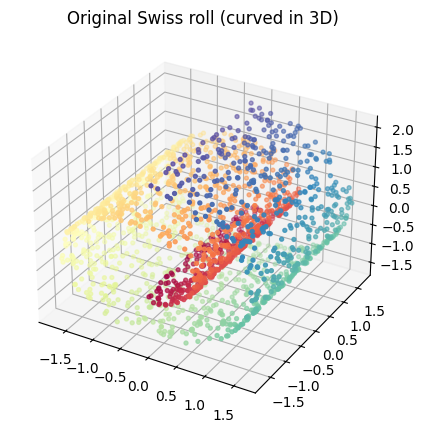

Adaptive epsilon = 0.271


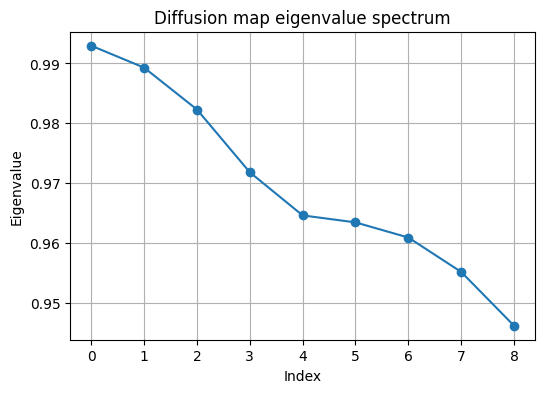

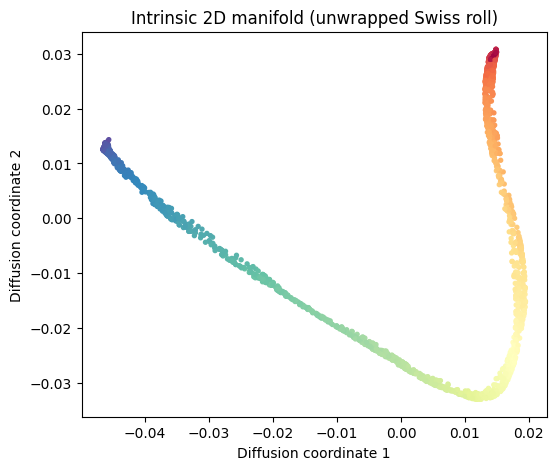

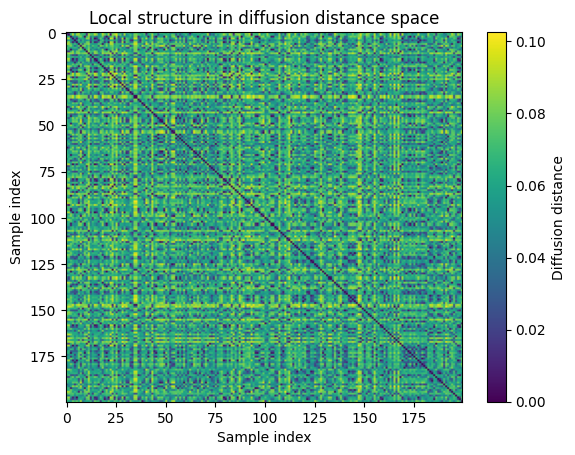

In [14]:
# =============================================
# 1. Imports and data
# =============================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from scipy.sparse.linalg import eigsh

# Generate nonlinear data
X, color = make_swiss_roll(n_samples=2000, noise=0.05)
X = StandardScaler().fit_transform(X)

# Visualize the raw manifold
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], c=color, cmap='Spectral', s=8)
ax.set_title("Original Swiss roll (curved in 3D)")
plt.show()


# =============================================
# 2. Build Gaussian affinity kernel
# =============================================
D = pairwise_distances(X)
# Adaptive bandwidth = median distance to 10th nearest neighbor
k = 10
eps = np.median(np.sort(D, axis=1)[:, k])
print(f"Adaptive epsilon = {eps:.3f}")

# Compute Gaussian kernel
K = np.exp(-D**2 / (2 * eps**2))


# =============================================
# 3. Density normalization (alpha correction)
# =============================================
alpha = 0.5
q = np.sum(K, axis=1)
K_alpha = K / np.outer(q**alpha, q**alpha)

# Row-normalize to Markov matrix
P = K_alpha / np.sum(K_alpha, axis=1, keepdims=True)


# =============================================
# 4. Diffusion eigen-decomposition
# =============================================
n_evecs = 10
vals, vecs = eigsh(P, k=n_evecs)
# Sort eigenpairs descending
idx = np.argsort(-vals)
vals, vecs = vals[idx], vecs[:, idx]

# Skip trivial first mode (constant)
eigvals = vals[1:]
coords = vecs[:, 1:4] * vals[1:4]   # first 3 diffusion coordinates


# =============================================
# 5. Visualize spectrum and embedding
# =============================================

plt.figure(figsize=(6,4))
plt.plot(eigvals, 'o-')
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.title("Diffusion map eigenvalue spectrum")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(coords[:,0], coords[:,1], c=color, cmap='Spectral', s=8)
plt.xlabel("Diffusion coordinate 1")
plt.ylabel("Diffusion coordinate 2")
plt.title("Intrinsic 2D manifold (unwrapped Swiss roll)")
plt.show()


# =============================================
# 6. (Optional) Diffusion distance matrix
# =============================================
# A geometry-aware distance reflecting manifold connectivity
diff_coords = vecs[:, 1:5] * vals[1:5]
diff_dist = np.linalg.norm(diff_coords[:, None, :] - diff_coords[None, :, :], axis=2)

plt.imshow(diff_dist[:200, :200], cmap='viridis', aspect='auto')
plt.colorbar(label="Diffusion distance")
plt.title("Local structure in diffusion distance space")
plt.xlabel("Sample index"); plt.ylabel("Sample index")
plt.show()


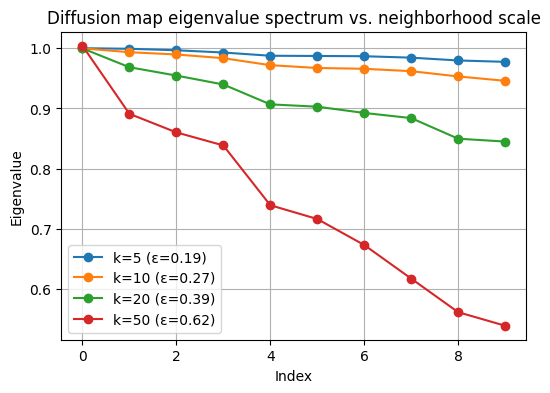

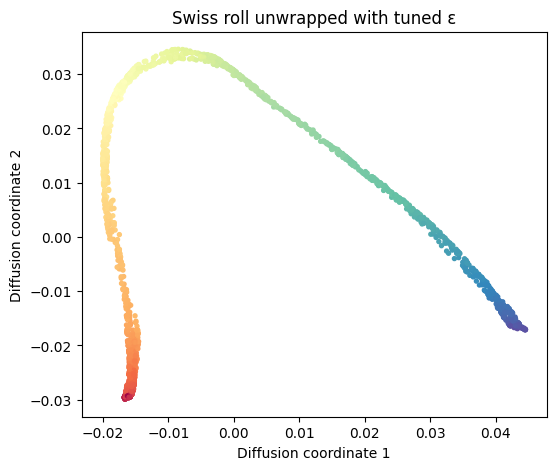

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from scipy.sparse.linalg import eigsh

# --- Data ---
X, color = make_swiss_roll(n_samples=2000, noise=0.05)
X = StandardScaler().fit_transform(X)
D = pairwise_distances(X)

# --- Loop over different neighborhood scales ---
plt.figure(figsize=(6,4))
for k in [5, 10, 20, 50]:
    eps = np.median(np.sort(D, axis=1)[:, k])  # adaptive epsilon
    K = np.exp(-D**2 / (2 * eps**2))
    
    # density normalization
    alpha = 0.5
    q = K.sum(axis=1)
    K = K / np.outer(q**alpha, q**alpha)
    
    # row-stochastic normalization
    P = K / K.sum(axis=1, keepdims=True)
    
    # eigen decomposition
    vals, _ = eigsh(P, k=10)
    vals = np.sort(vals)[::-1]
    
    plt.plot(vals, 'o-', label=f'k={k} (ε={eps:.2f})')

plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.title("Diffusion map eigenvalue spectrum vs. neighborhood scale")
plt.legend()
plt.grid(True)
plt.show()

# --- pick the best ε (e.g., k=10) and visualize embedding ---
k = 10
eps = np.median(np.sort(D, axis=1)[:, k])
K = np.exp(-D**2 / (2 * eps**2))
alpha = 0.5
q = K.sum(1)
K = K / np.outer(q**alpha, q**alpha)
P = K / K.sum(1, keepdims=True)

vals, vecs = eigsh(P, k=6)
idx = np.argsort(-vals)
vals, vecs = vals[idx], vecs[:, idx]

coords = vecs[:,1:3] * vals[1:3]

plt.figure(figsize=(6,5))
plt.scatter(coords[:,0], coords[:,1], c=color, cmap='Spectral', s=8)
plt.xlabel("Diffusion coordinate 1")
plt.ylabel("Diffusion coordinate 2")
plt.title("Swiss roll unwrapped with tuned ε")
plt.show()
